# MAE-HAR SSL Ablation Visualization

Unified notebook for visualizing MAE pretraining ablation results:

- **Section A — Mask Ratio Ablation** (enc12 layer-probing across mask ratios 0.50 / 0.75 / 0.875 / 0.95, layers 1/3/6/9/12)
- **Section B — Mask Strategy Ablation** (enc6, mask_ratio=0.75, strategies random / freq / mixed / time)
- **Section C — Patch Size Ablation** (enc6, mask_ratio=0.75, square patches 3x3 / 5x5 / 7x7 / 11x11 / 13x13)
- **Section D — Mask Strategy Ablation (enc12)** (same design as Section B, rerun at encoder_depth=12)

All sections share the same loading, grouping, and plotting utilities (defined once below) so the
two ablations are visualized consistently and any fix to the loader benefits both.

Edit `RESULTS_DIR` / `FIG_DIR` in the config cell to point at your actual results directory before running.

In [94]:
print("tst")

tst


In [95]:
import json
import re
from collections import defaultdict
from pathlib import Path

In [96]:


import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# from pathlib import Path

# outdir_base = Path("./figs")
# outdir_base.mkdir(parents=True, exist_ok=True)


# -- Paths --------------------------------------------------------------
# Point these at wherever your MAE-HAR result JSONs live.
RESULTS_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/results")
FIG_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_SPLITS = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
SPLIT_LABELS = {
    "test_id": "ID (in-distribution)",
    "test_cross_device": "Cross-Device",
    "test_cross_env": "Cross-Env",
    "test_cross_user": "Cross-User",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

## Shared loading & grouping utilities

In [97]:
def load_matching_results(directory, filters, debug=False):
    """
    Recursively load all *.json result files under `directory` whose `args`
    dict matches every key/value in `filters`. A filter value of None means
    "no constraint on that key". Values are cast defensively (float/int)
    since some older training runs may have serialized args as strings.

    With debug=True, prints a [match]/[skip reason] line per candidate file --
    the fastest way to diagnose an empty result list.
    """
    results = []
    candidates = sorted(Path(directory).rglob("*.json"))
    if debug:
        print(f"[debug] found {len(candidates)} .json files under {directory} (recursive)")

    for fp in candidates:
        try:
            data = json.loads(fp.read_text())
        except (json.JSONDecodeError, UnicodeDecodeError) as e:
            if debug:
                print(f"[skip] {fp.name}: failed to parse ({e})")
            continue

        args = data.get("args")
        if args is None:
            if debug:
                print(f"[skip] {fp.name}: no args key")
            continue

        reasons = []
        for key, expected in filters.items():
            if expected is None:
                continue
            actual = args.get(key)
            if actual is None:
                reasons.append(f"{key} missing from args")
                continue
            try:
                if isinstance(expected, float):
                    if not np.isclose(float(actual), expected):
                        reasons.append(f"{key}={actual!r} != {expected}")
                elif isinstance(expected, int):
                    if int(actual) != expected:
                        reasons.append(f"{key}={actual!r} != {expected}")
                else:
                    if str(actual) != str(expected):
                        reasons.append(f"{key}={actual!r} != {expected!r}")
            except (TypeError, ValueError):
                reasons.append(f"{key}={actual!r} not comparable to {expected!r}")

        if reasons:
            if debug:
                print(f"[skip] {fp.name}: " + "; ".join(reasons))
            continue

        if debug:
            print(f"[match] {fp.name}")
        results.append(data)
    return results


def group_by(results, key_fn):
    """Group loaded results by an arbitrary key function, e.g.
    key_fn=lambda r: r['args']['mask_strategy']  or  key_fn=lambda r: r['args']['mask_ratio']
    """
    groups = defaultdict(list)
    for r in results:
        groups[key_fn(r)].append(r)
    return dict(groups)


def get_layers(result):
    first_ckpt = next(iter(result["evals"].values()))
    layers = list(first_ckpt.keys())
    layers.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return layers


def get_checkpoints(result):
    ckpts = list(result["evals"].keys())
    ckpts.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return ckpts

## Shared plotting utilities

In [98]:
def plot_loss_curve_by_group(groups, outdir, filename, title, colors=None, group_label_fmt="{k}"):
    """One loss curve per group key (mean +/- std across runs in that group).
    Runs within a group may have different loss_log lengths if a job is still training or
    was interrupted/restarted mid-run -- in that case, all runs in that group are truncated
    to the shortest common length before computing mean/std, with a warning printed so it's
    clear the curve reflects partial data for that group."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for key in sorted(groups.keys(), key=str):
        runs = groups[key]
        lengths = [len(r["loss_log"]) for r in runs]
        min_len = min(lengths)
        if len(set(lengths)) > 1:
            print(f"[warn] group={key}: loss_log lengths differ {lengths} -- truncating all runs to the shortest ({min_len} epochs) for this curve")
        epochs = np.array([pt["epoch"] for pt in runs[0]["loss_log"][:min_len]])
        loss_matrix = np.array([[pt["loss"] for pt in r["loss_log"][:min_len]] for r in runs])
        mean_loss = loss_matrix.mean(axis=0)
        std_loss = loss_matrix.std(axis=0)
        color = colors.get(key) if colors else None
        label = group_label_fmt.format(k=key) + f" (n={len(runs)})"
        ax.plot(epochs, mean_loss, label=label, color=color, linewidth=1.5)
        ax.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.15)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE Reconstruction Loss")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_final_accuracy_by_group(groups, outdir, filename, title, metric="lp_acc", layer=None,
                                  colors=None, group_label_fmt="{k}"):
    """Grouped bar chart: final-epoch metric per test split, one bar-group per key in `groups`.
    Each bar gets a value label (mean, 3 decimals) printed just above its error-bar cap."""
    keys = sorted(groups.keys(), key=str)
    x = np.arange(len(TEST_SPLITS))
    width = 0.8 / len(keys)

    fig, ax = plt.subplots(figsize=(9, 5))
    bar_groups = []  # (bars, means, stds) per key, collected for label placement after ylim is known
    for i, key in enumerate(keys):
        runs = groups[key]
        target_layer = layer or get_layers(runs[0])[-1]
        means, stds = [], []
        for split in TEST_SPLITS:
            vals = []
            for r in runs:
                final_ckpt = get_checkpoints(r)[-1]
                vals.append(r["evals"][final_ckpt][target_layer][split][metric])
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        color = colors.get(key) if colors else None
        label = group_label_fmt.format(k=key) + f" (n={len(runs)})"
        bars = ax.bar(x + i * width, means, width, yerr=stds, capsize=3, label=label, color=color)
        bar_groups.append((bars, means, stds))

    ax.set_xticks(x + width * (len(keys) - 1) / 2)
    ax.set_xticklabels([SPLIT_LABELS[s] for s in TEST_SPLITS])
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # Add headroom above the tallest error-bar cap so value labels don't get clipped,
    # then place each label just above its own bar's error-bar cap.
    tallest = max(m + s for _, means, stds in bar_groups for m, s in zip(means, stds))
    ax.set_ylim(top=tallest * 1.15)
    label_offset = tallest * 0.02
    for bars, means, stds in bar_groups:
        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width() / 2, m + s + label_offset, f"{m:.3f}",
                    ha="center", va="bottom", fontsize=8)

    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_summary_table_image(groups, outdir, filename, title, metric="lp_acc", layer=None,
                              group_label_fmt="{k}"):
    """Rendered table image: rows=group key (with n), columns=test split,
    cell text = 'mean +/- std'. Best value per column highlighted green, worst red.
    """
    keys = sorted(groups.keys(), key=str)
    mean_matrix = np.zeros((len(keys), len(TEST_SPLITS)))
    std_matrix = np.zeros((len(keys), len(TEST_SPLITS)))
    n_per_key = []

    for i, key in enumerate(keys):
        runs = groups[key]
        n_per_key.append(len(runs))
        target_layer = layer or get_layers(runs[0])[-1]
        for j, split in enumerate(TEST_SPLITS):
            vals = []
            for r in runs:
                final_ckpt = get_checkpoints(r)[-1]
                vals.append(r["evals"][final_ckpt][target_layer][split][metric])
            mean_matrix[i, j] = np.mean(vals)
            std_matrix[i, j] = np.std(vals)

    row_labels = [f"{group_label_fmt.format(k=k)} (n={n})" for k, n in zip(keys, n_per_key)]
    col_labels = [SPLIT_LABELS[s] for s in TEST_SPLITS]
    cell_text = [[f"{mean_matrix[i, j]:.4f} +/- {std_matrix[i, j]:.3f}" for j in range(len(TEST_SPLITS))]
                 for i in range(len(keys))]

    cell_colors = [["white"] * len(TEST_SPLITS) for _ in keys]
    for j in range(len(TEST_SPLITS)):
        col_vals = mean_matrix[:, j]
        cell_colors[int(np.argmax(col_vals))][j] = "#c8f0c8"   # best = light green
        cell_colors[int(np.argmin(col_vals))][j] = "#f5c6c6"   # worst = light red

    fig_height = 0.6 + 0.45 * len(keys)
    fig, ax = plt.subplots(figsize=(2.4 * len(TEST_SPLITS) + 2, fig_height))
    ax.axis("off")
    table = ax.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
                      cellColours=cell_colors, cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#dfe6f0")
    ax.set_title(title + "\n(green=best, red=worst per column)", fontsize=12, pad=20)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_layer_probing(result, outdir, filename, checkpoint=None, title_suffix=""):
    """Layer-wise KNN vs LP accuracy at a given checkpoint, one subplot per test split.
    Also plots F1 if the metric 'f1' exists in the eval dict for layers."""
    ckpts = get_checkpoints(result)
    checkpoint = checkpoint or ckpts[-1]
    layers = get_layers(result)
    layer_ids = [int(re.search(r"\d+", l).group()) for l in layers]

    fig, axes = plt.subplots(1, len(TEST_SPLITS), figsize=(5 * len(TEST_SPLITS), 4.5), sharey=True)
    for ax, split in zip(axes, TEST_SPLITS):
        knn_acc = [result["evals"][checkpoint][l][split].get("knn_acc") for l in layers]
        lp_acc = [result["evals"][checkpoint][l][split].get("lp_acc") for l in layers]
        knn_f1 = [result["evals"][checkpoint][l][split].get("knn_f1") for l in layers]
        lp_f1 = [result["evals"][checkpoint][l][split].get("lp_f1") for l in layers]

        ax.plot(layer_ids, knn_acc, "o-", label="KNN acc", color="tab:blue")
        ax.plot(layer_ids, lp_acc, "s-", label="LP acc", color="tab:orange")
        if any(v is not None for v in knn_f1):
            ax.plot(layer_ids, knn_f1, "o--", label="KNN F1", color="tab:blue", alpha=0.5)
        if any(v is not None for v in lp_f1):
            ax.plot(layer_ids, lp_f1, "s--", label="LP F1", color="tab:orange", alpha=0.5)

        ax.set_title(SPLIT_LABELS[split])
        ax.set_xlabel("Encoder Layer")
        ax.set_xticks(layer_ids)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Accuracy / F1")
    axes[0].legend(fontsize=9)
    fig.suptitle(f"Layer-wise Probing @ {checkpoint}{title_suffix}")
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_epoch_layer_heatmap(result, outdir, filename, split="test_cross_device", metric="lp_acc", title_suffix=""):
    """Epoch x layer heatmap for one experiment / test split / metric --
    useful for seeing whether LP saturation happens at the same epoch across layer depths."""
    ckpts = get_checkpoints(result)
    layers = get_layers(result)
    layer_ids = [int(re.search(r"\d+", l).group()) for l in layers]
    epoch_ids = [int(re.search(r"\d+", c).group()) for c in ckpts]

    matrix = np.zeros((len(layers), len(ckpts)))
    for i, l in enumerate(layers):
        for j, c in enumerate(ckpts):
            matrix[i, j] = result["evals"][c][l][split][metric]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    im = ax.imshow(matrix, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(ckpts)))
    ax.set_xticklabels(epoch_ids)
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels(layer_ids)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Encoder Layer")
    ax.set_title(f"{SPLIT_LABELS[split]} - {metric}{title_suffix}")
    for i in range(len(layers)):
        for j in range(len(ckpts)):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                     color="white" if matrix[i, j] < matrix.max() * 0.7 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, label=metric)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def print_summary_table(groups, layer=None, metric="lp_acc", group_label_fmt="{k}"):
    print(f"\n=== Summary: {metric} (mean +/- std across runs) ===")
    header = f"{'group':<14}" + "".join(f"{SPLIT_LABELS[s]:>20}" for s in TEST_SPLITS)
    print(header)
    for key in sorted(groups.keys(), key=str):
        runs = groups[key]
        target_layer = layer or get_layers(runs[0])[-1]
        row = f"{group_label_fmt.format(k=key):<14}"
        for split in TEST_SPLITS:
            vals = []
            for r in runs:
                final_ckpt = get_checkpoints(r)[-1]
                vals.append(r["evals"][final_ckpt][target_layer][split][metric])
            row += f"{np.mean(vals):>14.4f} +/- {np.std(vals):<4.3f}"
        print(row)

In [99]:
print("tst")

tst


In [100]:
PATCH_COLORS = {
    11: "#0EA5E9",
    13: "#22C55E",
    15: "#EAB308",
    17: "#F97316",
    19: "#DC2626",
    21: "#9333EA",
}
PATCH_COLOR_LIST = list(PATCH_COLORS.values())

ALL_GROUP_KEYS = [
    # mask ratios
    0.5, 0.75, 0.875, 0.95,
    # mask strategies
    "2d", "freq", "mixed", "random", "time",
    # patch sizes (cover every size you've used, including old ones)
    3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 29,
]

GROUP_COLORS = {}
for i, key in enumerate(ALL_GROUP_KEYS):
    if key in PATCH_COLORS:
        GROUP_COLORS[key] = PATCH_COLORS[key]
    else:
        GROUP_COLORS[key] = PATCH_COLOR_LIST[i % len(PATCH_COLOR_LIST)]

## Section A — Mask Ratio Ablation (enc12 layer-probing)

Filters on `mask_strategy="random"`, `encoder_depth=12`, `patch_h=29`, `patch_w=25`, and groups by
`mask_ratio`. This is the currently-running enc12 layer-probing experiment (mask ratios x seeds x
eval_layers 1/3/6/9/12) — some (ratio, seed) combos may still be missing if that job hasn't finished yet,
which is expected and will just show up as a smaller `n` per ratio.

In [101]:
RATIO_FILTERS = {
    "mask_strategy": "random",
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False  # flip to True if 0 files match and you need to see why, per file

ratio_results = load_matching_results(RESULTS_DIR, RATIO_FILTERS, debug=DEBUG)
if not ratio_results:
    print("No mask-ratio-ablation (enc12) files matched. Set DEBUG=True above and re-run this cell.")
    ratio_groups = {}
else:
    ratio_groups = group_by(ratio_results, key_fn=lambda r: r["args"]["mask_ratio"])
    print(f"Found {len(ratio_results)} files across {len(ratio_groups)} mask ratios: "
          f"{ {k: len(v) for k, v in ratio_groups.items()} }")



Found 8 files across 4 mask ratios: {0.5: 2, 0.75: 2, 0.875: 2, 0.95: 2}


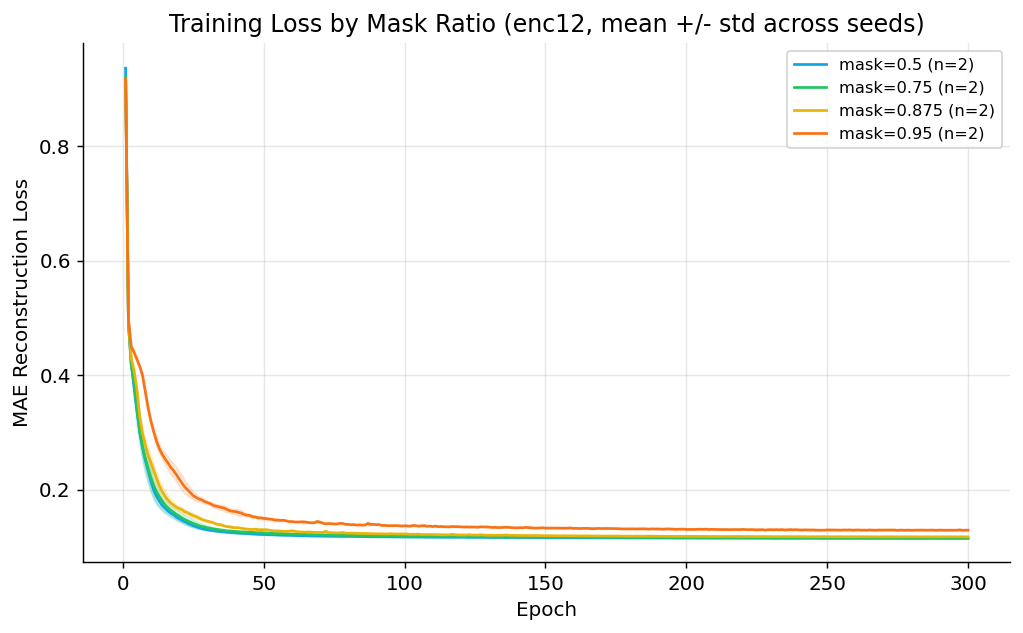

In [102]:
if ratio_groups:
    plot_loss_curve_by_group(
        ratio_groups, FIG_DIR, "ratio_loss_curve_enc12.png",
        title="Training Loss by Mask Ratio (enc12, mean +/- std across seeds)",
        colors=GROUP_COLORS, group_label_fmt="mask={k}",
    
    )

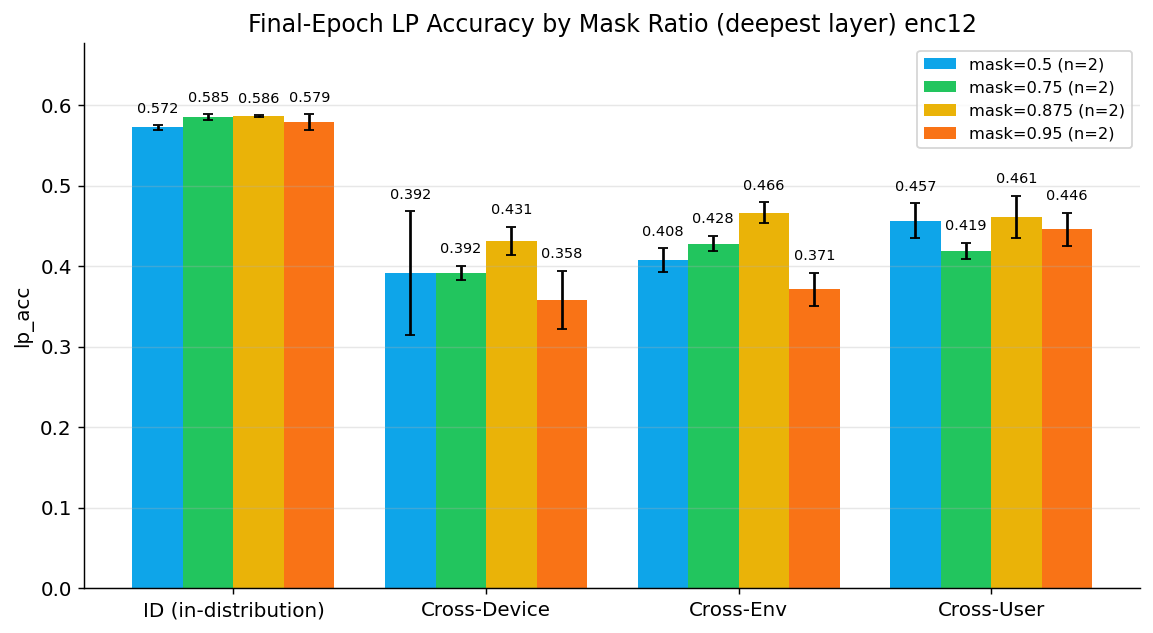

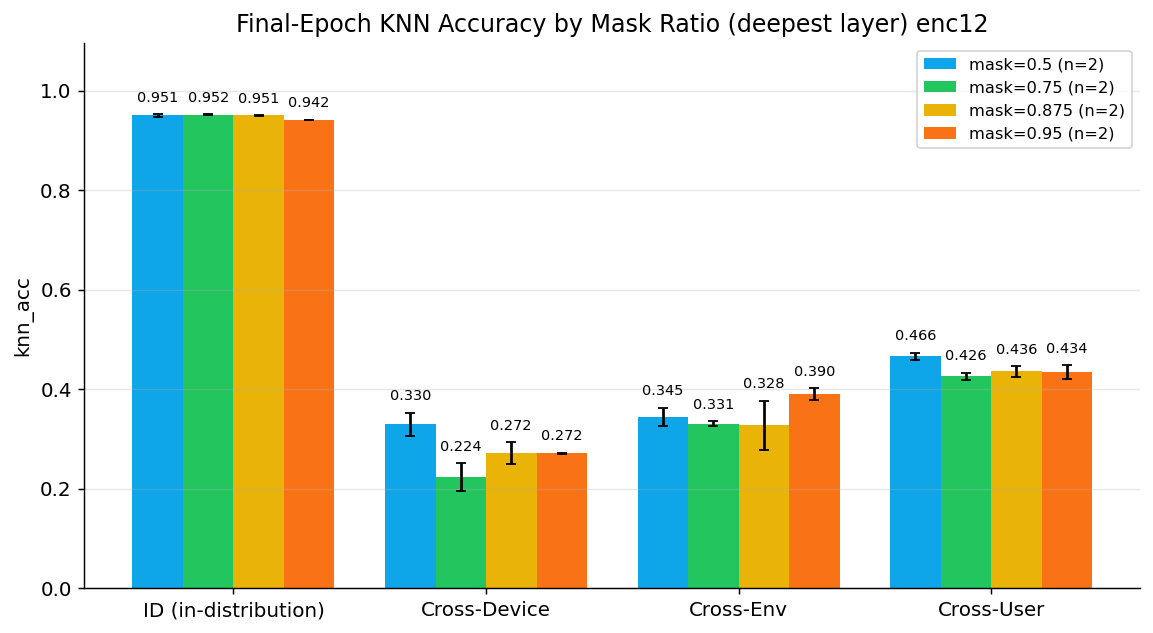

In [103]:
if ratio_groups:
    plot_final_accuracy_by_group(
        ratio_groups, FIG_DIR, "ratio_bar_lp_acc_enc12.png",
        title="Final-Epoch LP Accuracy by Mask Ratio (deepest layer) enc12",
        metric="lp_acc", colors=GROUP_COLORS, group_label_fmt="mask={k}",

    )
    plot_final_accuracy_by_group(
        ratio_groups, FIG_DIR, "ratio_bar_knn_acc_enc12.png",
        title="Final-Epoch KNN Accuracy by Mask Ratio (deepest layer) enc12",
        metric="knn_acc", colors=GROUP_COLORS, group_label_fmt="mask={k}",
    
    )

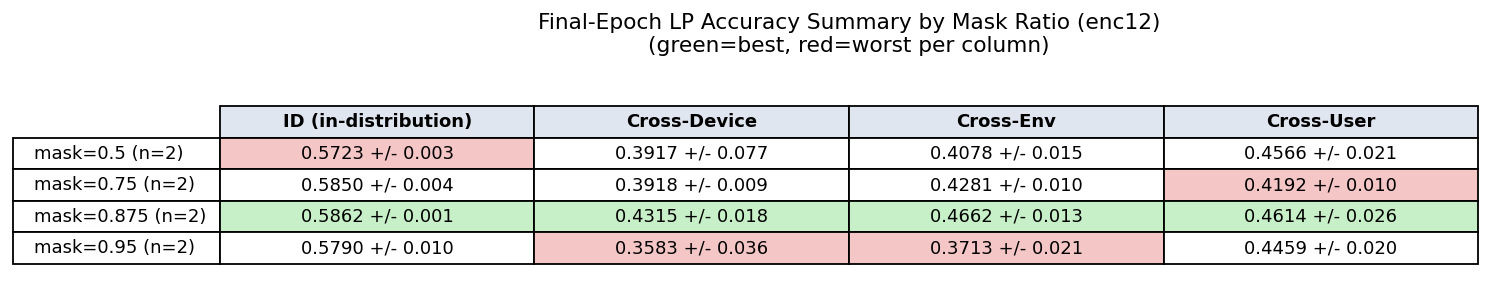

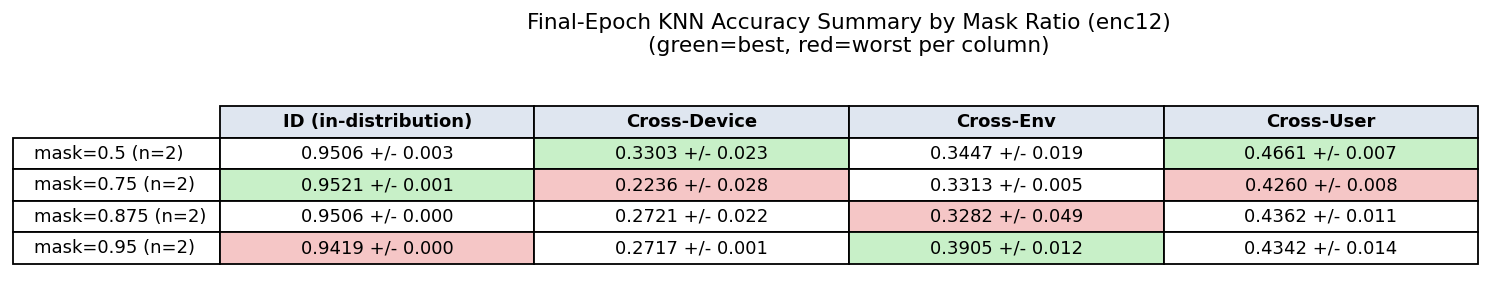


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.5723 +/- 0.003        0.3917 +/- 0.077        0.4078 +/- 0.015        0.4566 +/- 0.021
mask=0.75             0.5850 +/- 0.004        0.3918 +/- 0.009        0.4281 +/- 0.010        0.4192 +/- 0.010
mask=0.875            0.5862 +/- 0.001        0.4315 +/- 0.018        0.4662 +/- 0.013        0.4614 +/- 0.026
mask=0.95             0.5790 +/- 0.010        0.3583 +/- 0.036        0.3713 +/- 0.021        0.4459 +/- 0.020

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.9506 +/- 0.003        0.3303 +/- 0.023        0.3447 +/- 0.019        0.4661 +/- 0.007
mask=0.75             0.9521 +/- 0.001        0.2236 +/- 0.028        0.3313 +/- 0.005        0.4260 +/- 0.008
mask=0.875            0.9506 +/- 0.000 

In [104]:
if ratio_groups:
    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_lp_acc_enc12.png",
        title="Final-Epoch LP Accuracy Summary by Mask Ratio (enc12)",
        metric="lp_acc", group_label_fmt="mask={k}",
    )

    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_knn_enc12.png",
        title="Final-Epoch KNN Accuracy Summary by Mask Ratio (enc12)",
        metric="knn_acc", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_groups, metric="lp_acc", group_label_fmt="mask={k}")
    print_summary_table(ratio_groups, metric="knn_acc", group_label_fmt="mask={k}")

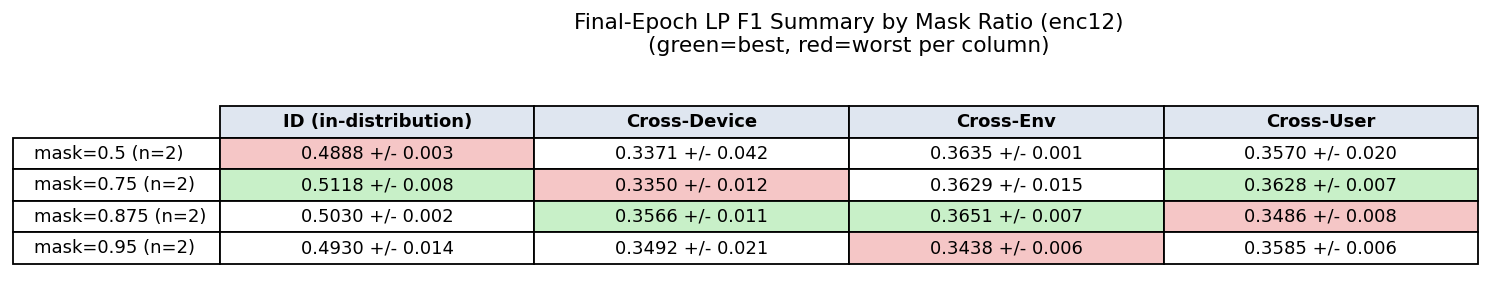

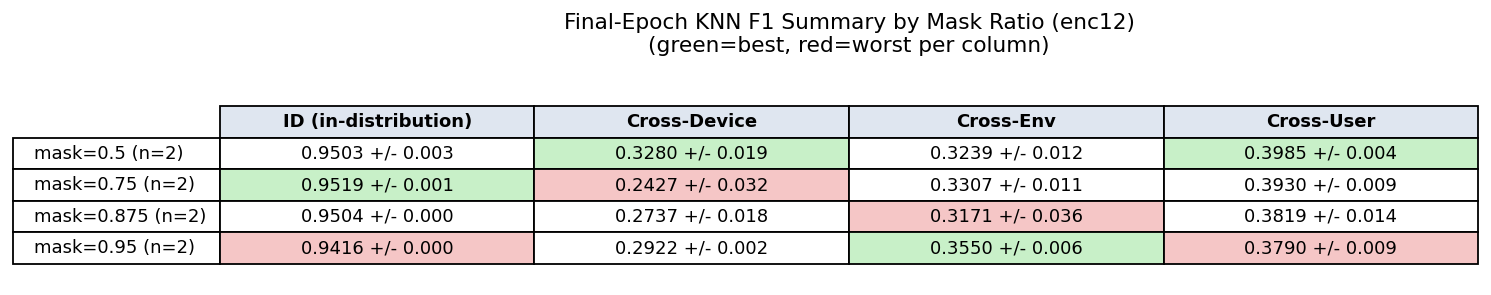


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.4888 +/- 0.003        0.3371 +/- 0.042        0.3635 +/- 0.001        0.3570 +/- 0.020
mask=0.75             0.5118 +/- 0.008        0.3350 +/- 0.012        0.3629 +/- 0.015        0.3628 +/- 0.007
mask=0.875            0.5030 +/- 0.002        0.3566 +/- 0.011        0.3651 +/- 0.007        0.3486 +/- 0.008
mask=0.95             0.4930 +/- 0.014        0.3492 +/- 0.021        0.3438 +/- 0.006        0.3585 +/- 0.006

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.9503 +/- 0.003        0.3280 +/- 0.019        0.3239 +/- 0.012        0.3985 +/- 0.004
mask=0.75             0.9519 +/- 0.001        0.2427 +/- 0.032        0.3307 +/- 0.011        0.3930 +/- 0.009
mask=0.875            0.9504 +/- 0.000   

In [105]:
if ratio_groups:
    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_lp_f1_enc12.png",
        title="Final-Epoch LP F1 Summary by Mask Ratio (enc12)",
        metric="lp_f1", group_label_fmt="mask={k}",
    )

    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_knn_f1_enc12.png",
        title="Final-Epoch KNN F1 Summary by Mask Ratio (enc12)",
        metric="knn_f1", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_groups, metric="lp_f1", group_label_fmt="mask={k}")
    print_summary_table(ratio_groups, metric="knn_f1", group_label_fmt="mask={k}")

**Per-ratio layer-wise probing.** For each mask ratio, plots KNN vs LP accuracy across encoder
layers 1/3/6/9/12 at the final checkpoint, using the first available seed as representative.

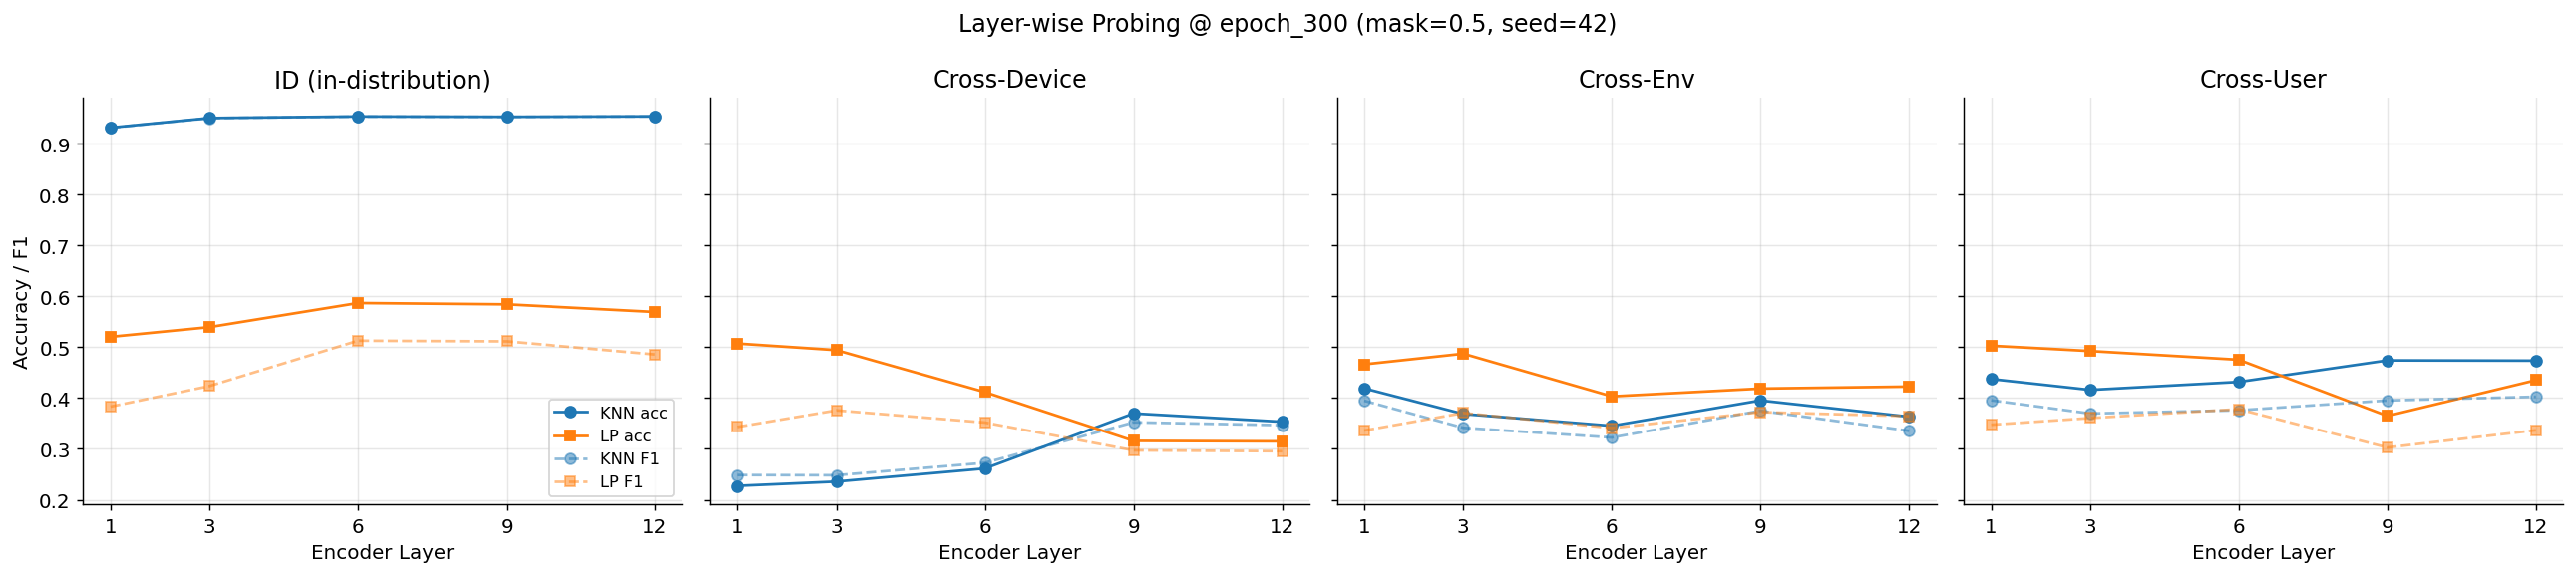

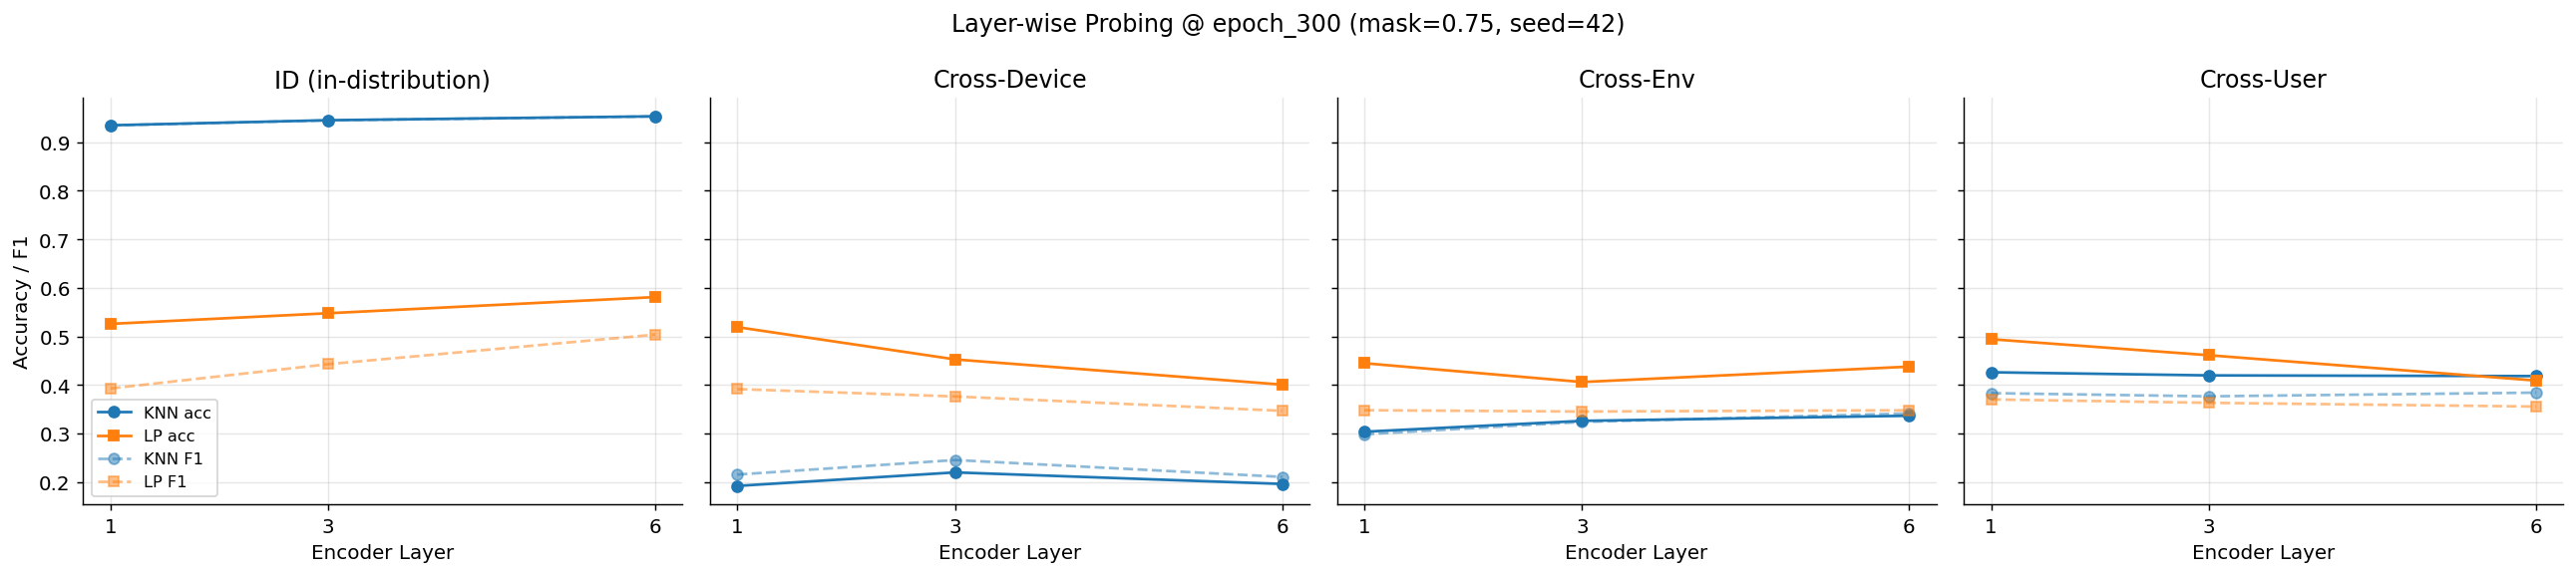

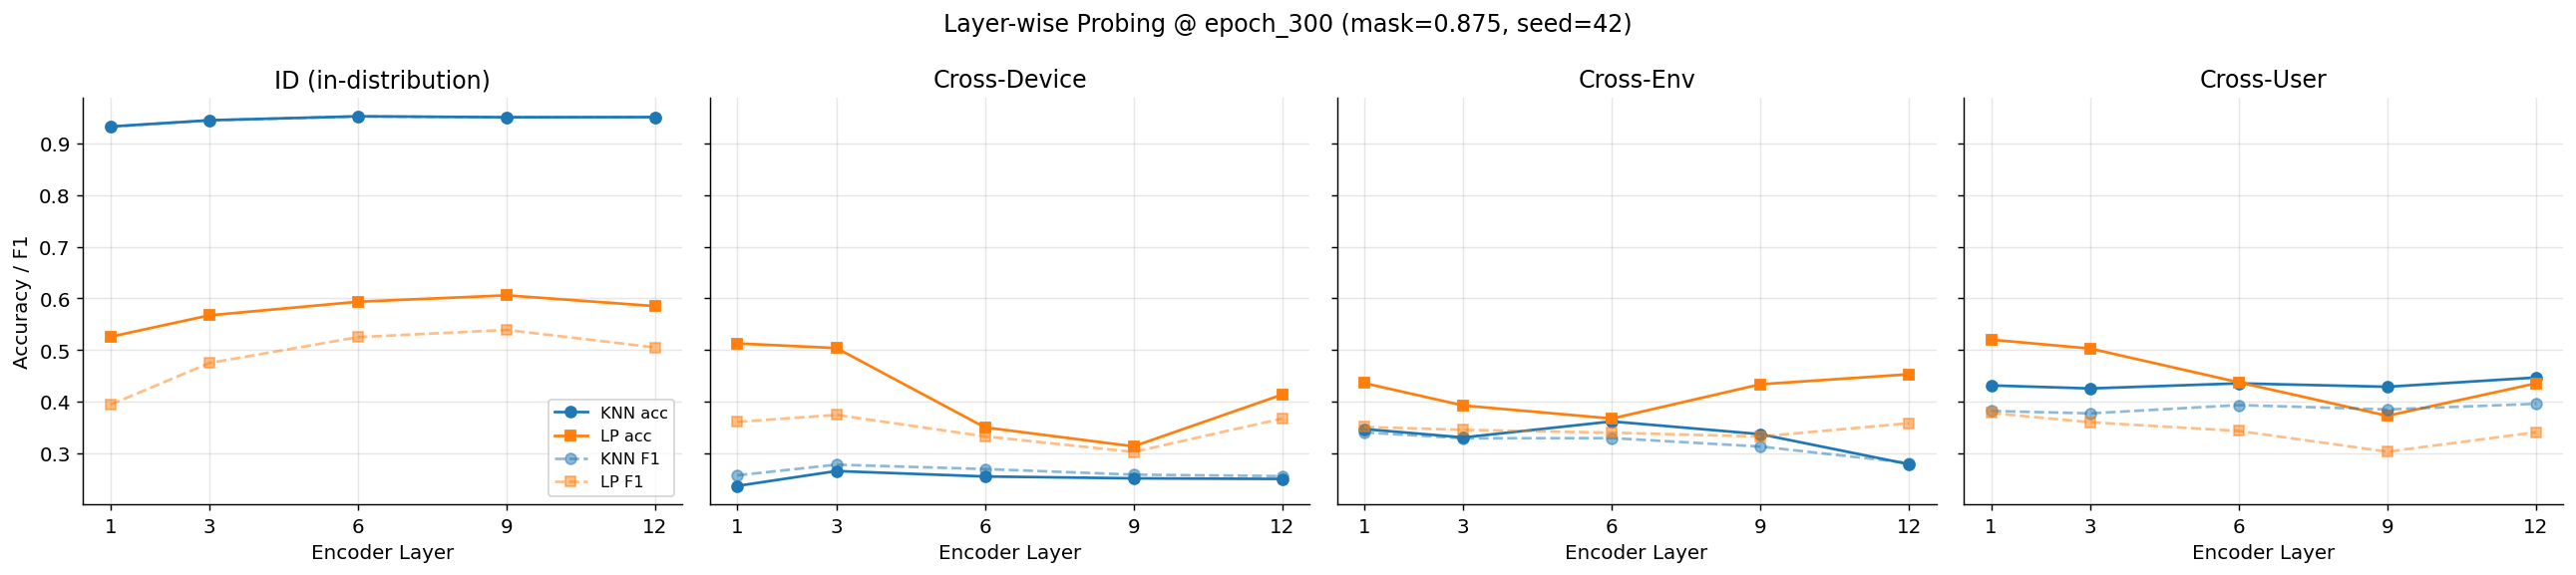

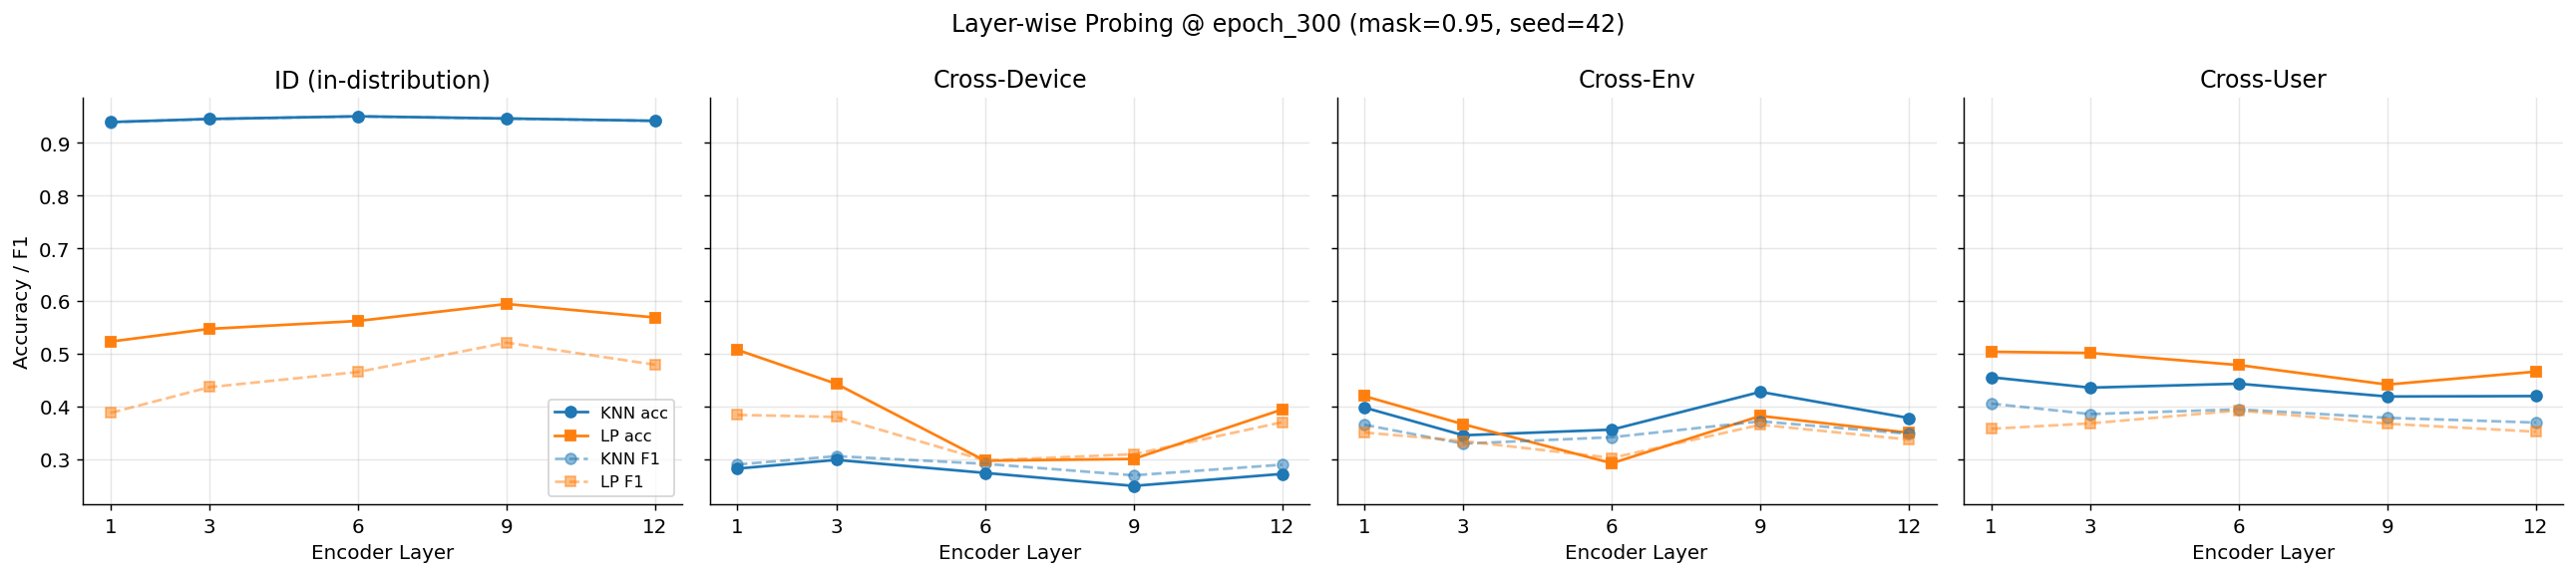

In [106]:
if ratio_groups:
    for ratio, runs in sorted(ratio_groups.items()):
        rep = runs[0]  # representative run (first available seed)
        plot_layer_probing(
            rep, FIG_DIR, f"ratio_layer_enc12_probing_mask{ratio}.png",
            title_suffix=f" (mask={ratio}, seed={rep['args'].get('seed')})",
        )

**Epoch x layer heatmap** (mask_ratio=0.75, cross_device split) — shows whether LP saturation
happens at the same training epoch across layer depths, or whether deeper layers need longer to converge.

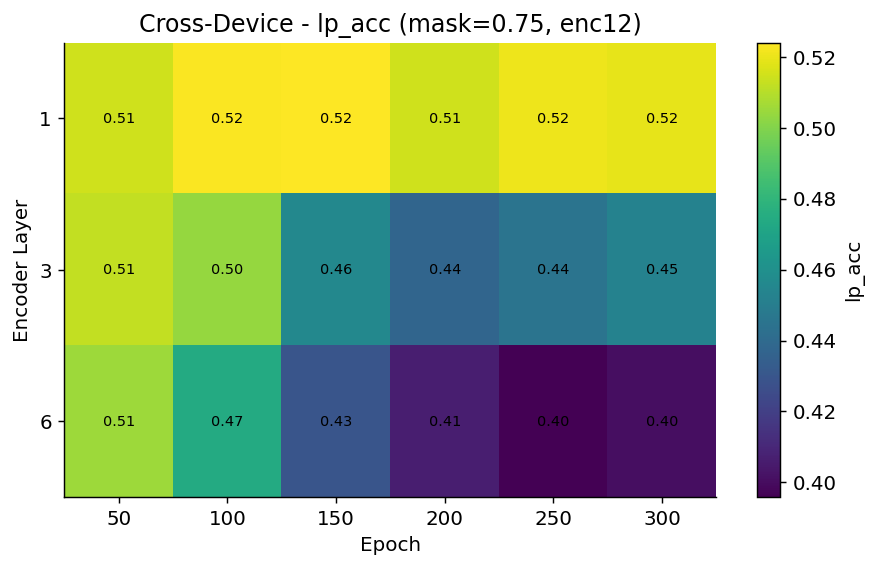

In [107]:
if 0.75 in ratio_groups:
    plot_epoch_layer_heatmap(
        ratio_groups[0.75][0], FIG_DIR, "ratio_heatmap_mask0.75_cross_device_enc12.png",
        split="test_cross_device", metric="lp_acc",
        title_suffix=" (mask=0.75, enc12)",
    )
else:
    print("mask_ratio=0.75 not found in ratio_groups -- skipping heatmap.")

## Section B — Mask Strategy Ablation (enc6, mask_ratio=0.75)

Filters on `mask_ratio=0.75`, `encoder_depth=6`, `patch_h=29`, `patch_w=25`, and groups by
`mask_strategy` (random / freq / mixed / time).

In [108]:
STRATEGY_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 6,
    "patch_h": 29,
    "patch_w": 25,
}

strategy_results = load_matching_results(RESULTS_DIR, STRATEGY_FILTERS, debug=DEBUG)
if not strategy_results:
    print("No mask-strategy-ablation (enc6, mask=0.75) files matched. Set DEBUG=True above and re-run.")
    strategy_groups = {}
else:
    strategy_groups = group_by(strategy_results, key_fn=lambda r: r["args"]["mask_strategy"])
    print(f"Found {len(strategy_results)} files across {len(strategy_groups)} strategies: "
          f"{ {k: len(v) for k, v in strategy_groups.items()} }")

# STRATEGY_COLORS = {"random": "tab:blue", "freq": "tab:green", "mixed": "tab:orange", "time": "tab:red"}
STRATEGY_COLORS = {"random": "#0EA5E9", "freq": "#22C55E", "mixed": "#EAB308", "time": "#F97316"}

Found 11 files across 5 strategies: {'2d': 2, 'freq': 2, 'mixed': 2, 'random': 3, 'time': 2}


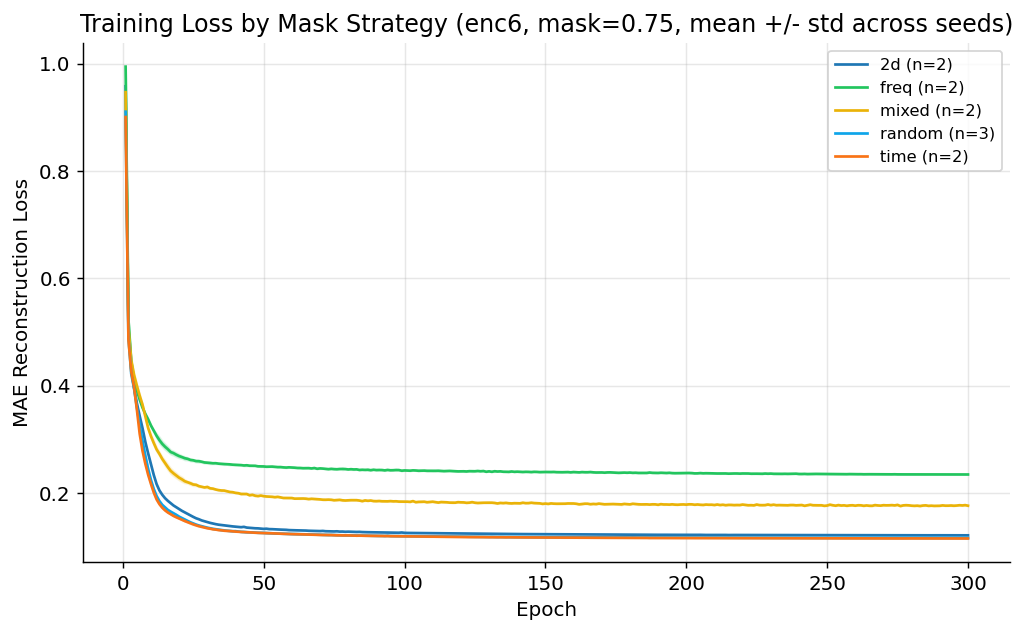

In [109]:
if strategy_groups:
    plot_loss_curve_by_group(
        strategy_groups, FIG_DIR, "strategy_loss_curve_enc6.png",
        title="Training Loss by Mask Strategy (enc6, mask=0.75, mean +/- std across seeds)",
        colors=STRATEGY_COLORS,
    )

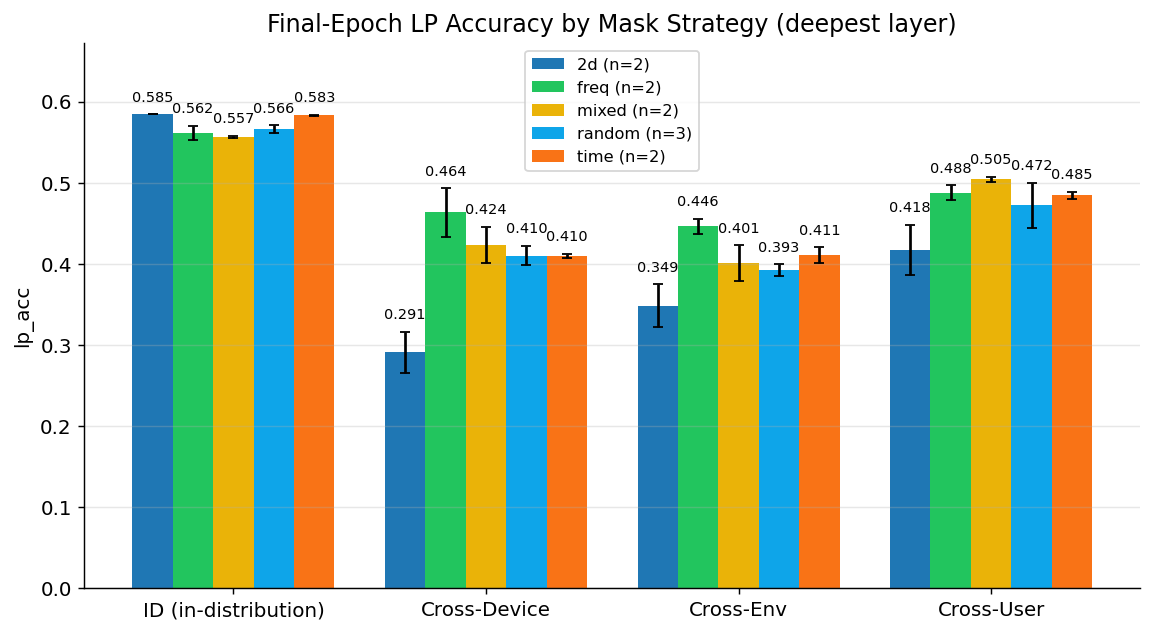

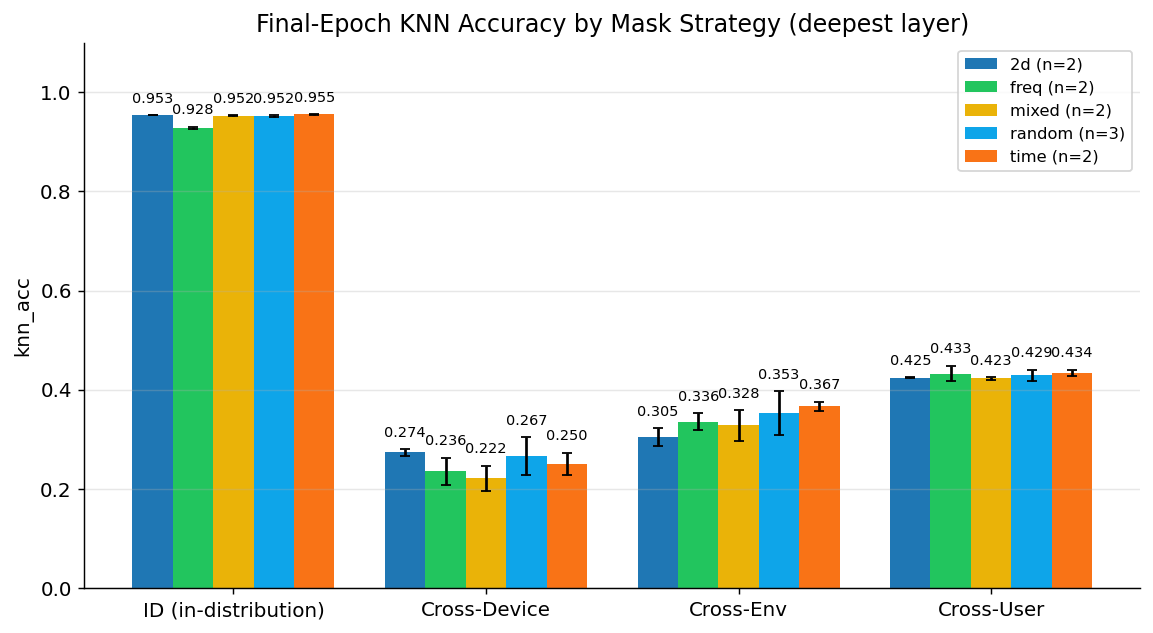

In [110]:
if strategy_groups:
    plot_final_accuracy_by_group(
        strategy_groups, FIG_DIR, "strategy_bar_lp_acc_enc6.png",
        title="Final-Epoch LP Accuracy by Mask Strategy (deepest layer)",
        metric="lp_acc", colors=STRATEGY_COLORS,
    )
    plot_final_accuracy_by_group(
        strategy_groups, FIG_DIR, "strategy_bar_knn_acc_enc6.png",
        title="Final-Epoch KNN Accuracy by Mask Strategy (deepest layer)",
        metric="knn_acc", colors=STRATEGY_COLORS,
    )

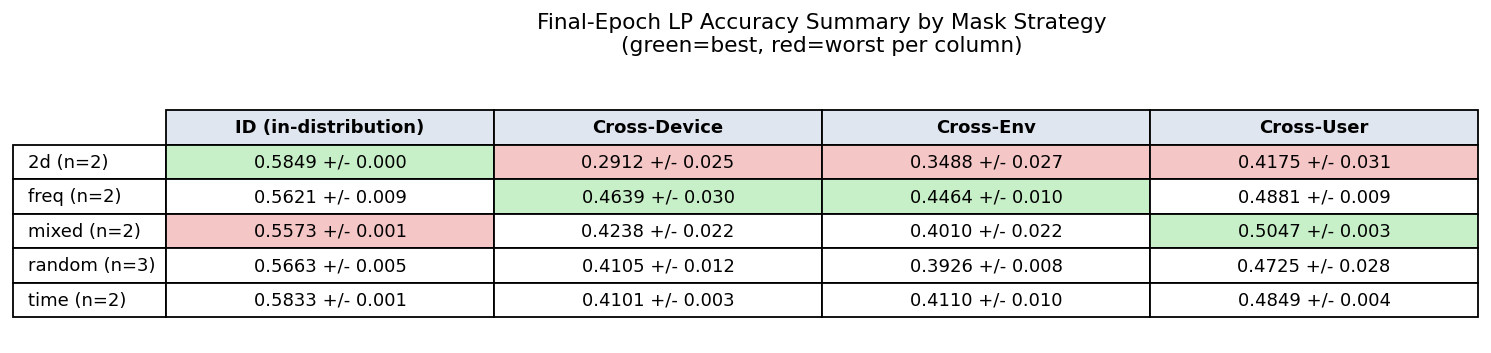

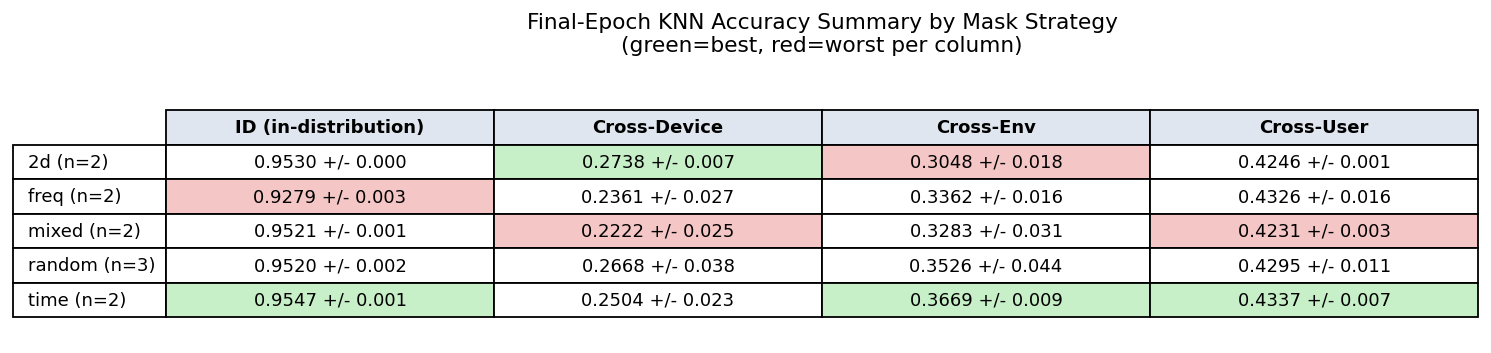


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.5849 +/- 0.000        0.2912 +/- 0.025        0.3488 +/- 0.027        0.4175 +/- 0.031
freq                  0.5621 +/- 0.009        0.4639 +/- 0.030        0.4464 +/- 0.010        0.4881 +/- 0.009
mixed                 0.5573 +/- 0.001        0.4238 +/- 0.022        0.4010 +/- 0.022        0.5047 +/- 0.003
random                0.5663 +/- 0.005        0.4105 +/- 0.012        0.3926 +/- 0.008        0.4725 +/- 0.028
time                  0.5833 +/- 0.001        0.4101 +/- 0.003        0.4110 +/- 0.010        0.4849 +/- 0.004

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.9530 +/- 0.000        0.2738 +/- 0.007        0.3048 +/- 0.018        0.4246 +/- 0.001
freq                  0.9279 +/- 0.003 

In [111]:
if strategy_groups:
    plot_summary_table_image(
        strategy_groups, FIG_DIR, "strategy_table_lp_acc_enc6.png",
        title="Final-Epoch LP Accuracy Summary by Mask Strategy",
        metric="lp_acc",
    )
    plot_summary_table_image(
        strategy_groups, FIG_DIR, "strategy_table_knn_acc_enc6.png",
        title="Final-Epoch KNN Accuracy Summary by Mask Strategy",
        metric="knn_acc",
    )
    print_summary_table(strategy_groups, metric="lp_acc")
    print_summary_table(strategy_groups, metric="knn_acc")

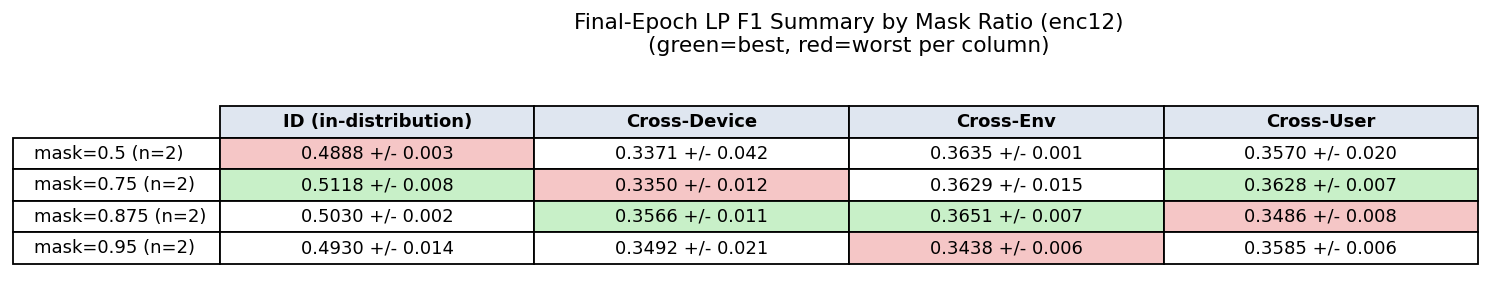

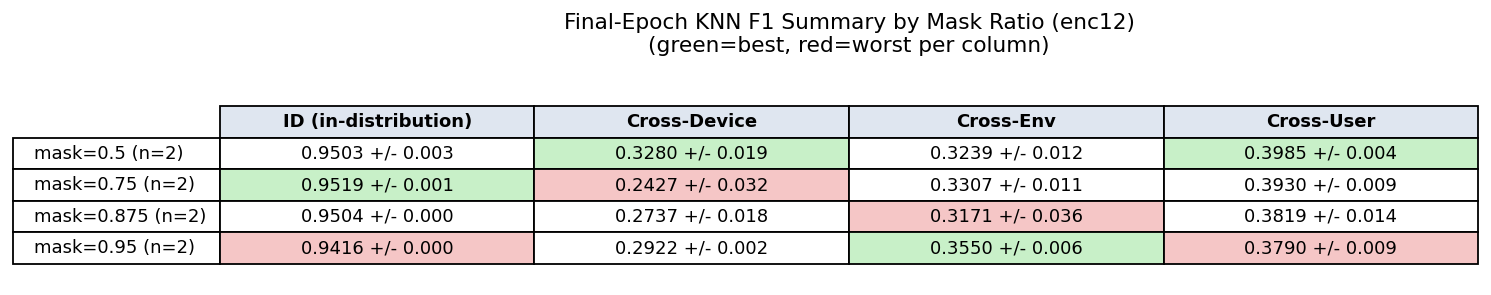


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.4888 +/- 0.003        0.3371 +/- 0.042        0.3635 +/- 0.001        0.3570 +/- 0.020
mask=0.75             0.5118 +/- 0.008        0.3350 +/- 0.012        0.3629 +/- 0.015        0.3628 +/- 0.007
mask=0.875            0.5030 +/- 0.002        0.3566 +/- 0.011        0.3651 +/- 0.007        0.3486 +/- 0.008
mask=0.95             0.4930 +/- 0.014        0.3492 +/- 0.021        0.3438 +/- 0.006        0.3585 +/- 0.006

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.9503 +/- 0.003        0.3280 +/- 0.019        0.3239 +/- 0.012        0.3985 +/- 0.004
mask=0.75             0.9519 +/- 0.001        0.2427 +/- 0.032        0.3307 +/- 0.011        0.3930 +/- 0.009
mask=0.875            0.9504 +/- 0.000   

In [112]:
if ratio_groups:
    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_lp_f1_enc12.png",
        title="Final-Epoch LP F1 Summary by Mask Ratio (enc12)",
        metric="lp_f1", group_label_fmt="mask={k}",
    )

    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_knn_f1_enc12.png",
        title="Final-Epoch KNN F1 Summary by Mask Ratio (enc12)",
        metric="knn_f1", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_groups, metric="lp_f1", group_label_fmt="mask={k}")
    print_summary_table(ratio_groups, metric="knn_f1", group_label_fmt="mask={k}")

## Section D — Mask Strategy Ablation (enc12, mask_ratio=0.75)

Same design as Section B, but rerun at `encoder_depth=12` instead of 6. Filters on
`mask_ratio=0.75`, `encoder_depth=12`, `patch_h=29`, `patch_w=25`, and groups by
`mask_strategy` (random / freq / mixed / time / 2d). Lets us check whether the
LP-vs-KNN divergence and the "2d is worst under LP" finding from the enc6 version
replicate at a deeper encoder.

In [113]:
STRATEGY_ENC12_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}

strategy_enc12_results = load_matching_results(RESULTS_DIR, STRATEGY_ENC12_FILTERS, debug=DEBUG)
if not strategy_enc12_results:
    print("No mask-strategy-ablation (enc12, mask=0.75) files matched. Set DEBUG=True above and re-run.")
    strategy_enc12_groups = {}
else:
    strategy_enc12_groups = group_by(strategy_enc12_results, key_fn=lambda r: r["args"]["mask_strategy"])
    print(f"Found {len(strategy_enc12_results)} files across {len(strategy_enc12_groups)} strategies: "
          f"{ {k: len(v) for k, v in strategy_enc12_groups.items()} }")

Found 10 files across 5 strategies: {'2d': 2, 'freq': 2, 'mixed': 2, 'random': 2, 'time': 2}


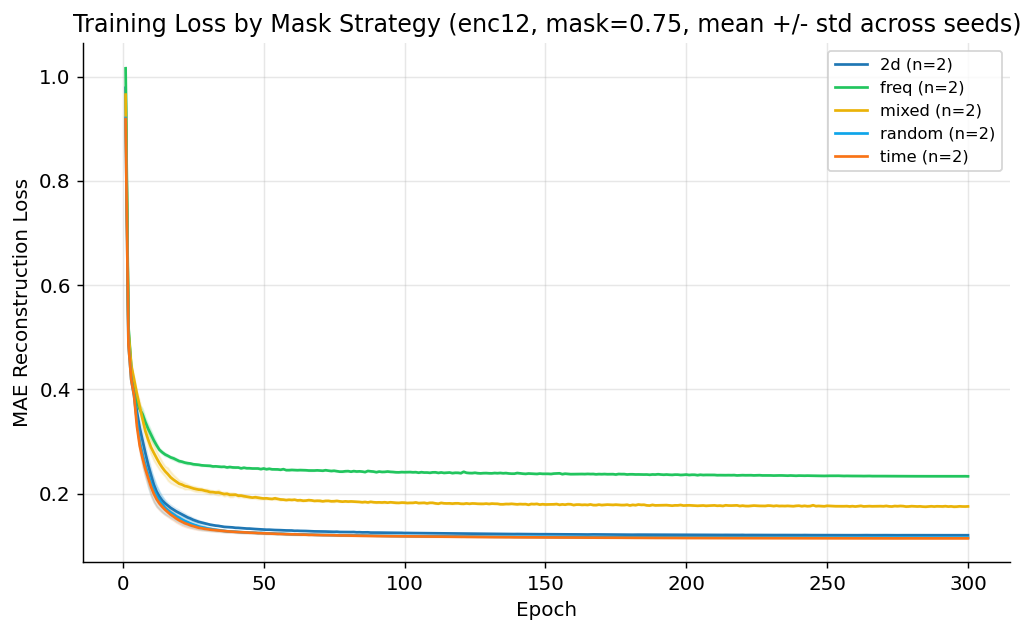

In [114]:
if strategy_enc12_groups:
    plot_loss_curve_by_group(
        strategy_enc12_groups, FIG_DIR, "strategy_enc12_loss_curve.png",
        title="Training Loss by Mask Strategy (enc12, mask=0.75, mean +/- std across seeds)",
        colors=STRATEGY_COLORS,
    )

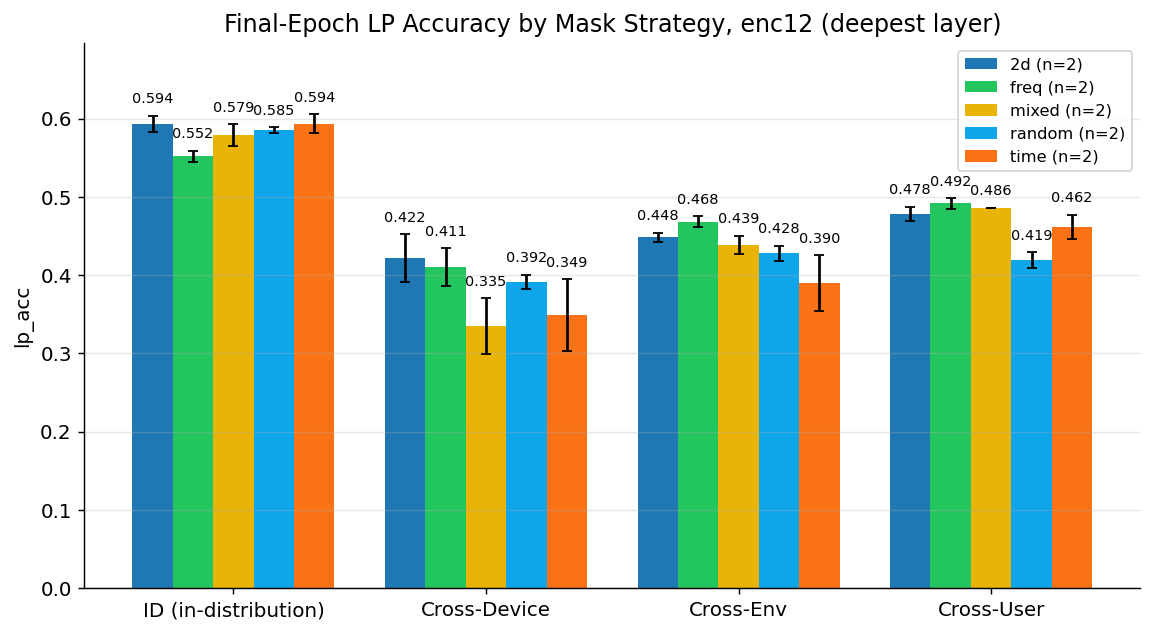

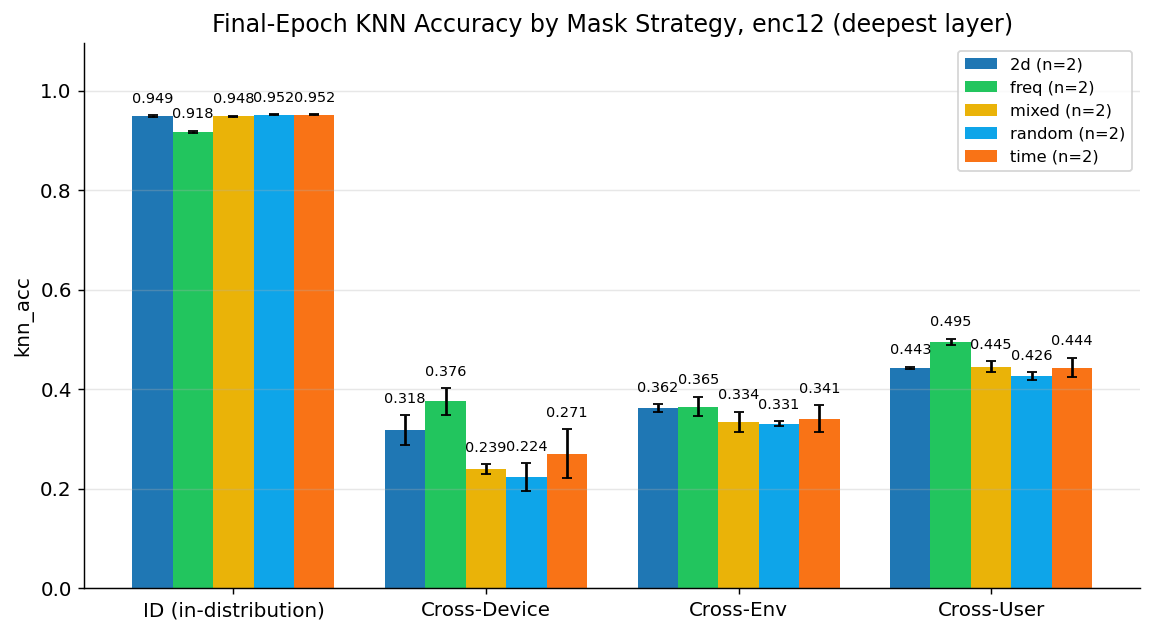

In [115]:
if strategy_enc12_groups:
    plot_final_accuracy_by_group(
        strategy_enc12_groups, FIG_DIR, "strategy_enc12_bar_lp_acc_enc12.png",
        title="Final-Epoch LP Accuracy by Mask Strategy, enc12 (deepest layer)",
        metric="lp_acc", colors=STRATEGY_COLORS,
    )
    plot_final_accuracy_by_group(
        strategy_enc12_groups, FIG_DIR, "strategy_enc12_bar_knn_acc_enc12.png",
        title="Final-Epoch KNN Accuracy by Mask Strategy, enc12 (deepest layer)",
        metric="knn_acc", colors=STRATEGY_COLORS,
    )

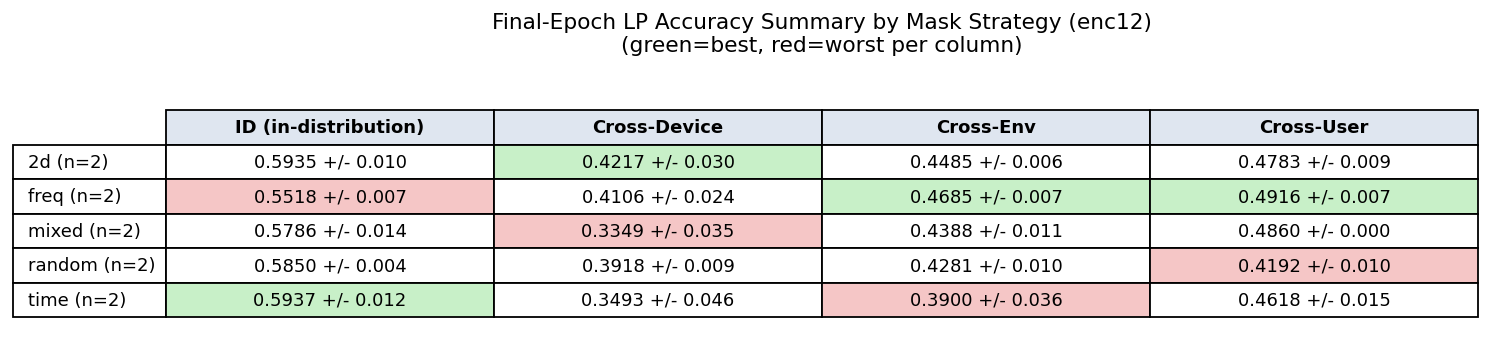

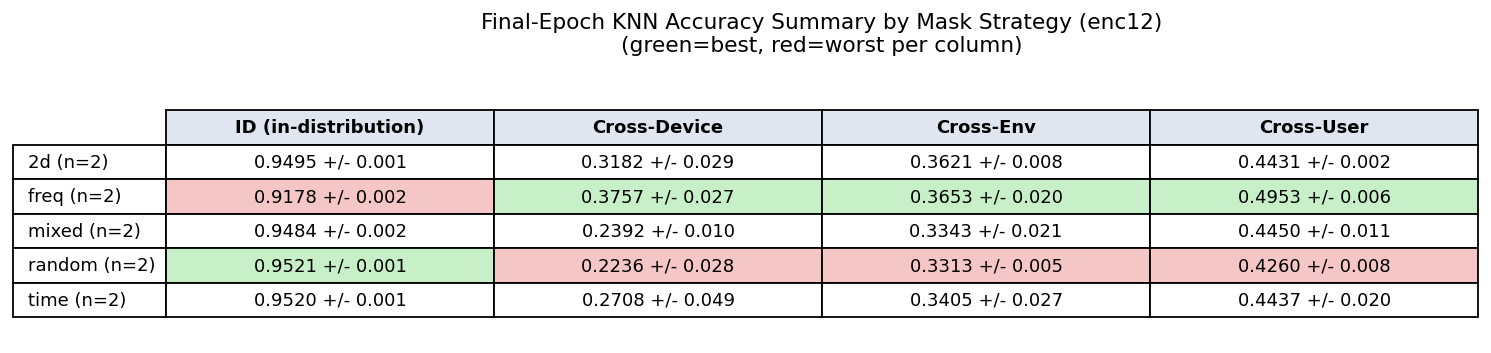


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.5935 +/- 0.010        0.4217 +/- 0.030        0.4485 +/- 0.006        0.4783 +/- 0.009
freq                  0.5518 +/- 0.007        0.4106 +/- 0.024        0.4685 +/- 0.007        0.4916 +/- 0.007
mixed                 0.5786 +/- 0.014        0.3349 +/- 0.035        0.4388 +/- 0.011        0.4860 +/- 0.000
random                0.5850 +/- 0.004        0.3918 +/- 0.009        0.4281 +/- 0.010        0.4192 +/- 0.010
time                  0.5937 +/- 0.012        0.3493 +/- 0.046        0.3900 +/- 0.036        0.4618 +/- 0.015

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.9495 +/- 0.001        0.3182 +/- 0.029        0.3621 +/- 0.008        0.4431 +/- 0.002
freq                  0.9178 +/- 0.002 

In [116]:
if strategy_enc12_groups:
    plot_summary_table_image(
        strategy_enc12_groups, FIG_DIR, "strategy_enc12_table_lp_acc_enc12.png",
        title="Final-Epoch LP Accuracy Summary by Mask Strategy (enc12)",
        metric="lp_acc",
    )
    plot_summary_table_image(
        strategy_enc12_groups, FIG_DIR, "strategy_enc12_table_knn_acc_enc12.png",
        title="Final-Epoch KNN Accuracy Summary by Mask Strategy (enc12)",
        metric="knn_acc",
    )
    print_summary_table(strategy_enc12_groups, metric="lp_acc")
    print_summary_table(strategy_enc12_groups, metric="knn_acc")

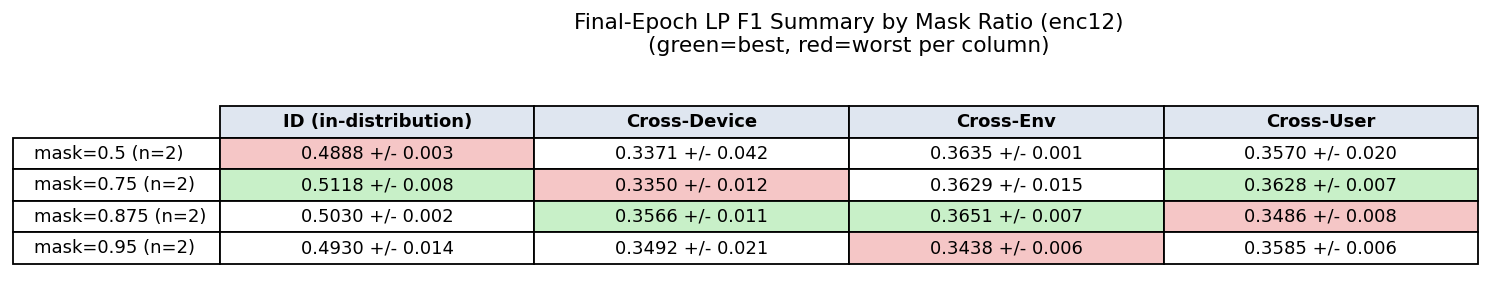

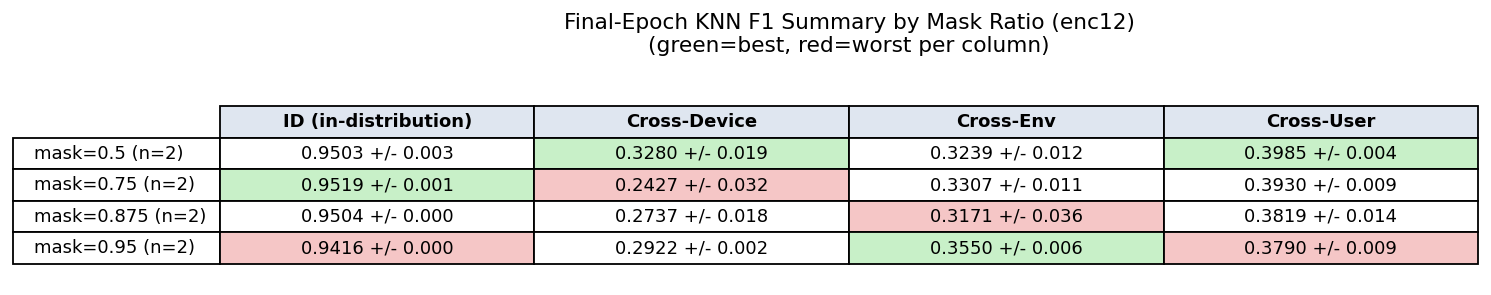


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.4888 +/- 0.003        0.3371 +/- 0.042        0.3635 +/- 0.001        0.3570 +/- 0.020
mask=0.75             0.5118 +/- 0.008        0.3350 +/- 0.012        0.3629 +/- 0.015        0.3628 +/- 0.007
mask=0.875            0.5030 +/- 0.002        0.3566 +/- 0.011        0.3651 +/- 0.007        0.3486 +/- 0.008
mask=0.95             0.4930 +/- 0.014        0.3492 +/- 0.021        0.3438 +/- 0.006        0.3585 +/- 0.006

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.9503 +/- 0.003        0.3280 +/- 0.019        0.3239 +/- 0.012        0.3985 +/- 0.004
mask=0.75             0.9519 +/- 0.001        0.2427 +/- 0.032        0.3307 +/- 0.011        0.3930 +/- 0.009
mask=0.875            0.9504 +/- 0.000   

In [117]:
if ratio_groups:
    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_lp_f1_enc12.png",
        title="Final-Epoch LP F1 Summary by Mask Ratio (enc12)",
        metric="lp_f1", group_label_fmt="mask={k}",
    )

    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_knn_f1_enc12.png",
        title="Final-Epoch KNN F1 Summary by Mask Ratio (enc12)",
        metric="knn_f1", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_groups, metric="lp_f1", group_label_fmt="mask={k}")
    print_summary_table(ratio_groups, metric="knn_f1", group_label_fmt="mask={k}")

**Cross-check against the enc6 version.** If `strategy_groups` (Section B) is already loaded in this
kernel session, the cell below prints both encoder depths side by side for `lp_acc`, so you can see at a
glance whether the enc6 ranking (e.g. "2d worst on Cross-Device") replicates at enc12, or whether it was
partly an artifact of depth-6 specifically.

In [118]:
if strategy_groups and strategy_enc12_groups:
    print("=== enc6 (Section B) ===")
    print_summary_table(strategy_groups, metric="lp_acc")
    print("\n=== enc12 (Section D) ===")
    print_summary_table(strategy_enc12_groups, metric="lp_acc")
else:
    print("Run Section B\'s cells first in this kernel session to enable the enc6-vs-enc12 comparison.")

=== enc6 (Section B) ===

=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.5849 +/- 0.000        0.2912 +/- 0.025        0.3488 +/- 0.027        0.4175 +/- 0.031
freq                  0.5621 +/- 0.009        0.4639 +/- 0.030        0.4464 +/- 0.010        0.4881 +/- 0.009
mixed                 0.5573 +/- 0.001        0.4238 +/- 0.022        0.4010 +/- 0.022        0.5047 +/- 0.003
random                0.5663 +/- 0.005        0.4105 +/- 0.012        0.3926 +/- 0.008        0.4725 +/- 0.028
time                  0.5833 +/- 0.001        0.4101 +/- 0.003        0.4110 +/- 0.010        0.4849 +/- 0.004

=== enc12 (Section D) ===

=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.5935 +/- 0.010        0.4217 +/- 0.030        0.4485 +/- 0.006        0.478

## Section C — Patch Size Ablation (enc6, mask_ratio=0.75)

Filters on `mask_ratio=0.75`, `encoder_depth=6`, `mask_strategy="random"`, and requires
`patch_h == patch_w` (square patches), grouping by patch size. Patch sizes 3/5/7/11/13 require
the input to be zero-padded to a size divisible by the patch size (since none of them evenly
divide the standard 232x500 input) -- see the padded-size table in the writeup for what each
patch size actually pads to.

In [119]:
PATCH_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 6,
    "mask_strategy": "random",
}

patch_results_all = load_matching_results(RESULTS_DIR, PATCH_FILTERS, debug=DEBUG)
patch_results = [r for r in patch_results_all
                  if r["args"].get("patch_h") is not None
                  and r["args"].get("patch_h") == r["args"].get("patch_w")]

if not patch_results:
    print("No patch-size-ablation (enc6, mask=0.75, random, square patch) files matched. "
          "Set DEBUG=True above and re-run.")
    patch_groups = {}
else:
    patch_groups = group_by(patch_results, key_fn=lambda r: r["args"]["patch_h"])
    print(f"Found {len(patch_results)} files across {len(patch_groups)} patch sizes: "
          f"{ {k: len(v) for k, v in patch_groups.items()} }")

PATCH_COLORS = {11: "#0EA5E9", 13: "#22C55E", 15: "#EAB308", 17: "#F97316", 19: "#DC2626"}

Found 10 files across 5 patch sizes: {11: 2, 13: 2, 15: 2, 17: 2, 19: 2}


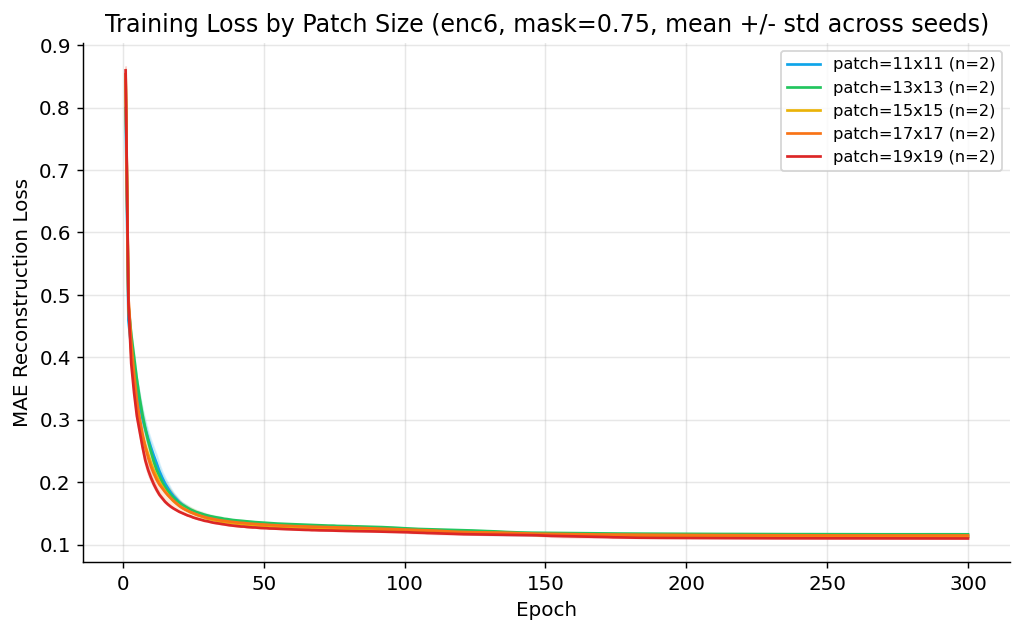

In [120]:
if patch_groups:
    plot_loss_curve_by_group(
        patch_groups, FIG_DIR, "patch_loss_curve_enc6.png",
        title="Training Loss by Patch Size (enc6, mask=0.75, mean +/- std across seeds)",
        colors=PATCH_COLORS, group_label_fmt="patch={k}x{k}",
    )

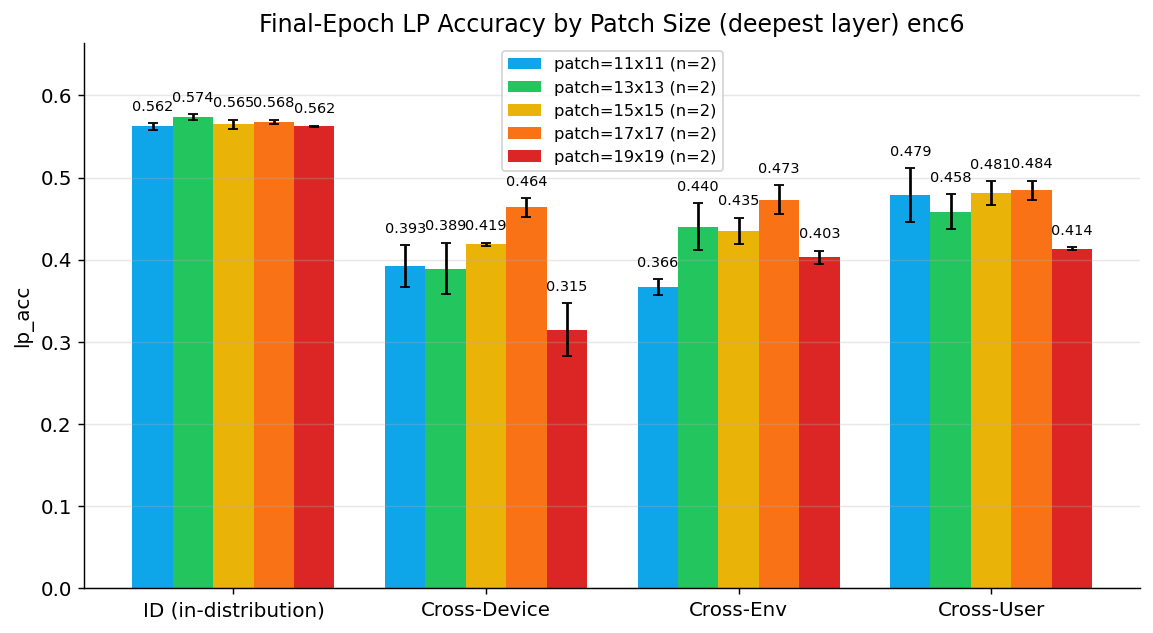

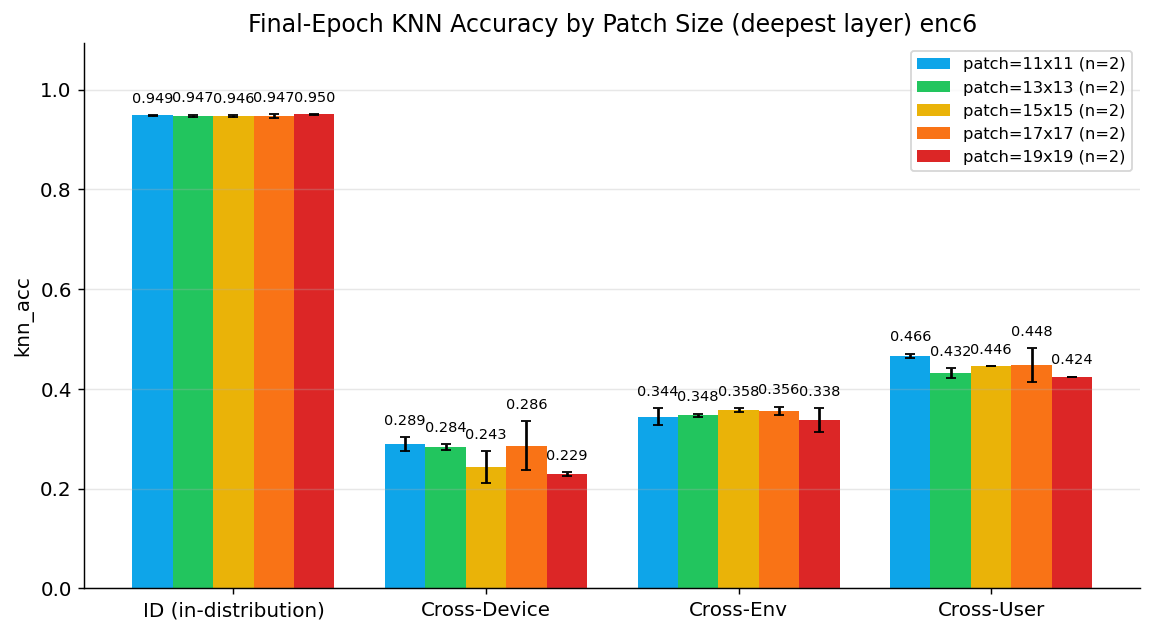

In [121]:
if patch_groups:
    plot_final_accuracy_by_group(
        patch_groups, FIG_DIR, "patch_bar_lp_acc_enc6.png",
        title="Final-Epoch LP Accuracy by Patch Size (deepest layer) enc6",
        metric="lp_acc", colors=PATCH_COLORS, group_label_fmt="patch={k}x{k}",
    )
    plot_final_accuracy_by_group(
        patch_groups, FIG_DIR, "patch_bar_knn_acc_enc6.png",
        title="Final-Epoch KNN Accuracy by Patch Size (deepest layer) enc6",
        metric="knn_acc", colors=PATCH_COLORS, group_label_fmt="patch={k}x{k}",
    )

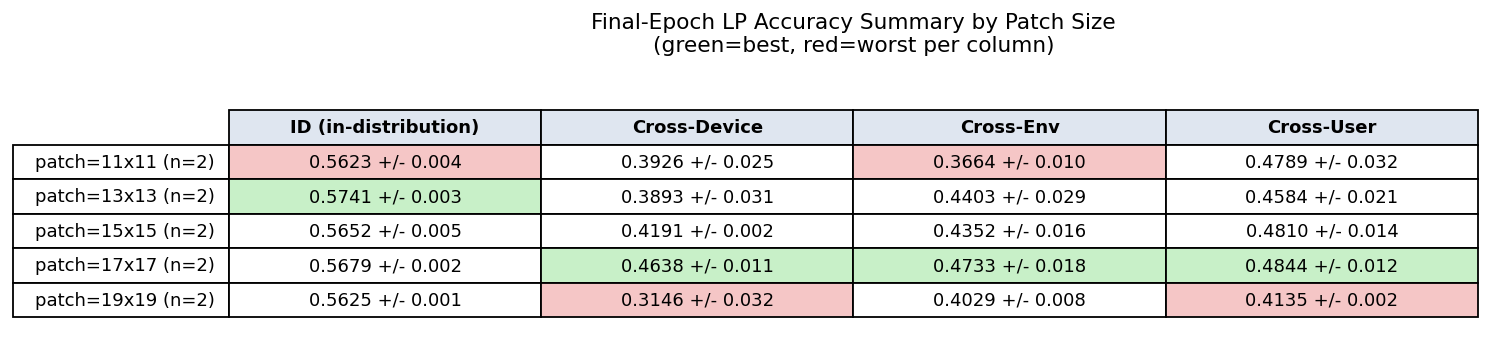

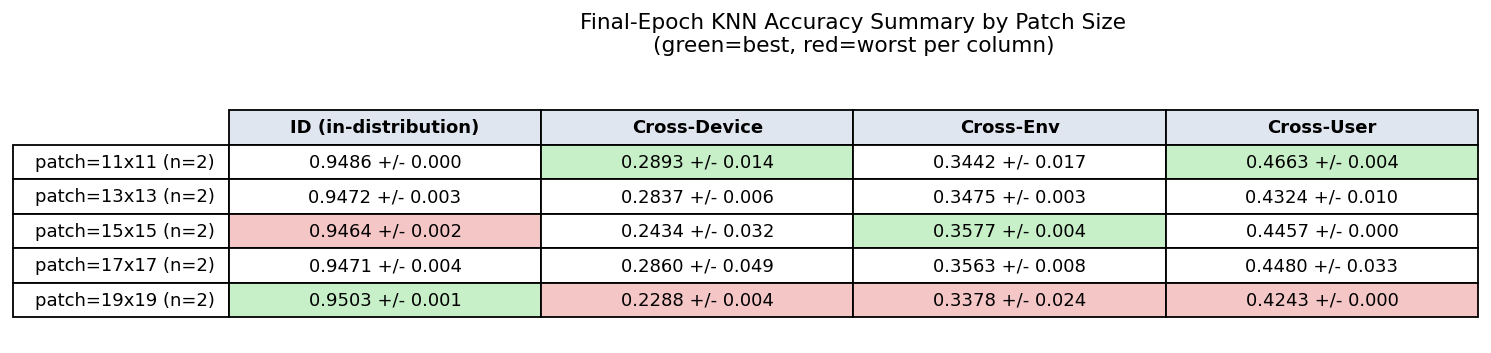


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.5623 +/- 0.004        0.3926 +/- 0.025        0.3664 +/- 0.010        0.4789 +/- 0.032
patch=13x13           0.5741 +/- 0.003        0.3893 +/- 0.031        0.4403 +/- 0.029        0.4584 +/- 0.021
patch=15x15           0.5652 +/- 0.005        0.4191 +/- 0.002        0.4352 +/- 0.016        0.4810 +/- 0.014
patch=17x17           0.5679 +/- 0.002        0.4638 +/- 0.011        0.4733 +/- 0.018        0.4844 +/- 0.012
patch=19x19           0.5625 +/- 0.001        0.3146 +/- 0.032        0.4029 +/- 0.008        0.4135 +/- 0.002

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.9486 +/- 0.000        0.2893 +/- 0.014        0.3442 +/- 0.017        0.4663 +/- 0.004
patch=13x13           0.9472 +/- 0.003 

In [122]:
if patch_groups:
    plot_summary_table_image(
        patch_groups, FIG_DIR, "patch_table_lp_acc_enc6.png",
        title="Final-Epoch LP Accuracy Summary by Patch Size",
        metric="lp_acc", group_label_fmt="patch={k}x{k}",
    )

    plot_summary_table_image(
        patch_groups, FIG_DIR, "patch_table_knn_acc_enc6.png",
        title="Final-Epoch KNN Accuracy Summary by Patch Size",
        metric="knn_acc", group_label_fmt="patch={k}x{k}",
    )

    print_summary_table(patch_groups, metric="lp_acc", group_label_fmt="patch={k}x{k}")
    print_summary_table(patch_groups, metric="knn_acc", group_label_fmt="patch={k}x{k}")

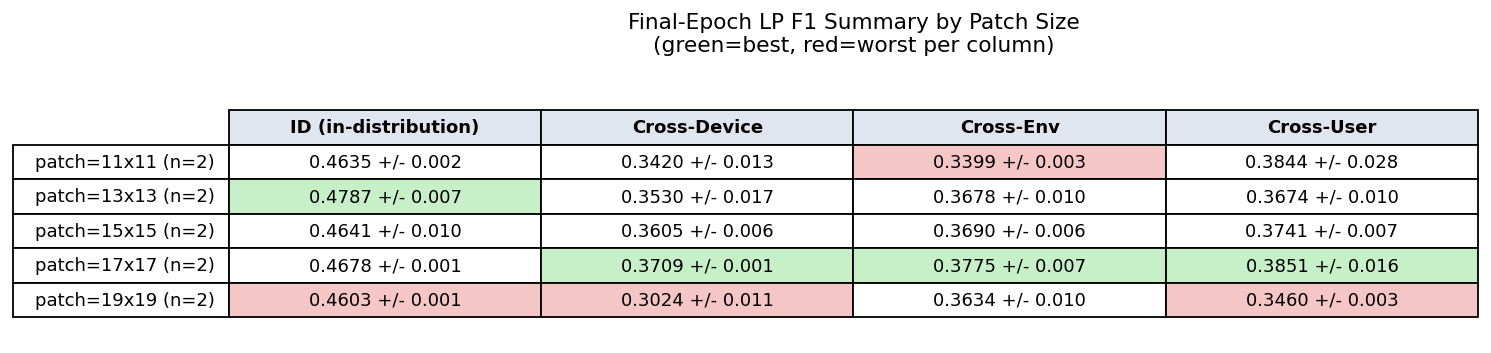

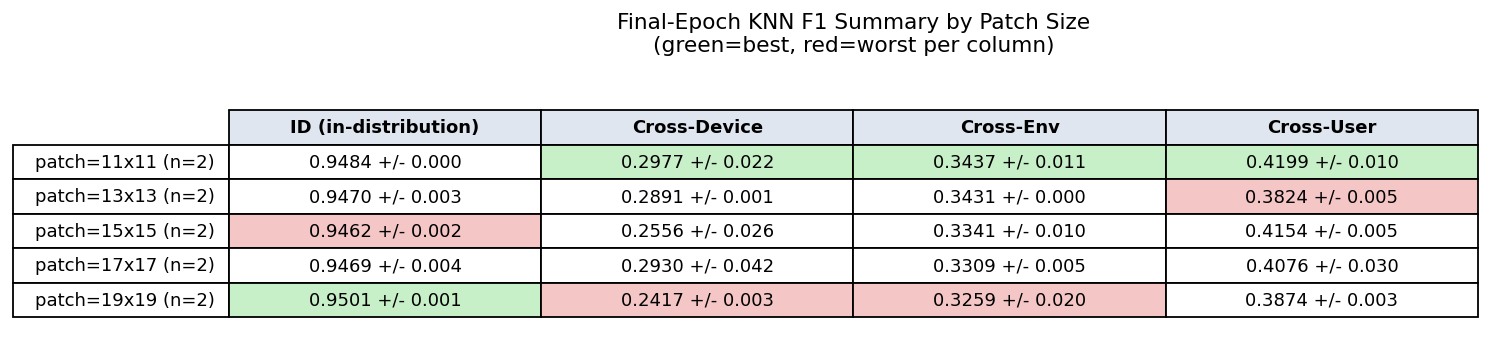


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.4635 +/- 0.002        0.3420 +/- 0.013        0.3399 +/- 0.003        0.3844 +/- 0.028
patch=13x13           0.4787 +/- 0.007        0.3530 +/- 0.017        0.3678 +/- 0.010        0.3674 +/- 0.010
patch=15x15           0.4641 +/- 0.010        0.3605 +/- 0.006        0.3690 +/- 0.006        0.3741 +/- 0.007
patch=17x17           0.4678 +/- 0.001        0.3709 +/- 0.001        0.3775 +/- 0.007        0.3851 +/- 0.016
patch=19x19           0.4603 +/- 0.001        0.3024 +/- 0.011        0.3634 +/- 0.010        0.3460 +/- 0.003

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.9484 +/- 0.000        0.2977 +/- 0.022        0.3437 +/- 0.011        0.4199 +/- 0.010
patch=13x13           0.9470 +/- 0.003   

In [123]:
if patch_groups:
    plot_summary_table_image(
        patch_groups, FIG_DIR, "patch_table_lp_f1_enc6.png",
        title="Final-Epoch LP F1 Summary by Patch Size",
        metric="lp_f1", group_label_fmt="patch={k}x{k}",
    )

    plot_summary_table_image(
        patch_groups, FIG_DIR, "patch_table_knn_f1_enc6.png",
        title="Final-Epoch KNN F1 Summary by Patch Size",
        metric="knn_f1", group_label_fmt="patch={k}x{k}",
    )

    print_summary_table(patch_groups, metric="lp_f1", group_label_fmt="patch={k}x{k}")
    print_summary_table(patch_groups, metric="knn_f1", group_label_fmt="patch={k}x{k}")

## Section E — Patch Size Ablation (enc12, mask_ratio=0.75)

Same design as Section C, but rerun at `encoder_depth=12`. Filters on `mask_ratio=0.75`,
`encoder_depth=12`, `mask_strategy="random"`, requires `patch_h == patch_w`, groups by patch size.

**Note `patch=11` uses a different `batch_size` than the rest of this sweep.** Doubling
`encoder_depth` doubles the cumulative attention memory (all layers' attention scores are
retained simultaneously during backward), so `patch=11` at `batch_size=128` is UNSAFE at
`encoder_depth=12` (23.4 GB cumulative, over the 20GB budget) even though it was fine at
`encoder_depth=6` (11.7 GB). To keep this sweep directly comparable to Section C's
11x11/13x13/15x15/17x17/19x19 (rather than dropping patch=11 and losing the overlap), the
launch script runs `patch=11` alone at `batch_size=96` (17.6 GB cumulative, safe) while
13x13/15x15/17x17/19x19 use the standard `batch_size=128`. This grouping logic (by `mask_ratio`,
`encoder_depth`, `mask_strategy`) does not care about `batch_size`, so the mixed-batch-size
files are grouped together with the rest exactly as if they all used the same batch_size --
if you want to sanity-check that the smaller batch_size for patch=11 isn't itself a
confound, compare its loss curve (Section E's loss-curve plot) to the others for a similar
convergence shape.

In [124]:

PATCH_ENC12_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 12,
    "mask_strategy": "random",
}

patch_enc12_results_all = load_matching_results(RESULTS_DIR, PATCH_ENC12_FILTERS, debug=DEBUG)
# Same is-not-None guard as Section C -- do not simplify this back to a bare .get()==.get()
# comparison, or legacy files missing both keys will silently pass and crash group_by later.
patch_enc12_results = [r for r in patch_enc12_results_all
                        if r["args"].get("patch_h") is not None
                        and r["args"].get("patch_h") == r["args"].get("patch_w")]

if not patch_enc12_results:
    print("No patch-size-ablation (enc12, mask=0.75, random, square patch) files matched. "
          "Set DEBUG=True above and re-run.")
    patch_enc12_groups = {}
else:
    patch_enc12_groups = group_by(patch_enc12_results, key_fn=lambda r: r["args"]["patch_h"])
    print(f"Found {len(patch_enc12_results)} files across {len(patch_enc12_groups)} patch sizes: "
          f"{ {k: len(v) for k, v in patch_enc12_groups.items()} }")

_patch_enc12_keys_sorted = sorted(patch_enc12_groups.keys()) if patch_enc12_groups else []
_patch_enc12_cmap = matplotlib.colormaps["plasma"]
_n_patch_enc12 = max(len(_patch_enc12_keys_sorted) - 1, 1)
PATCH_ENC12_COLORS = {k: _patch_enc12_cmap(i / _n_patch_enc12) for i, k in enumerate(_patch_enc12_keys_sorted)}

Found 12 files across 6 patch sizes: {11: 2, 13: 2, 15: 2, 17: 2, 19: 2, 21: 2}


[warn] group=19: loss_log lengths differ [250, 300] -- truncating all runs to the shortest (250 epochs) for this curve


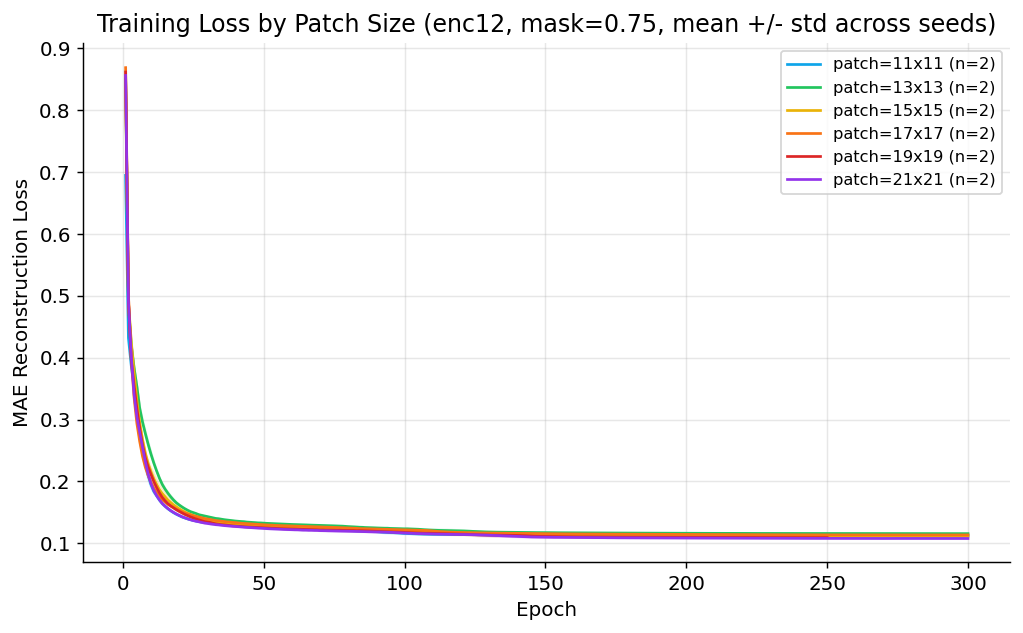

In [125]:
if patch_enc12_groups:
    plot_loss_curve_by_group(
        patch_enc12_groups, FIG_DIR, "patch_enc12_loss_curve.png",
        title="Training Loss by Patch Size (enc12, mask=0.75, mean +/- std across seeds)",
        colors=GROUP_COLORS, group_label_fmt="patch={k}x{k}",
    )

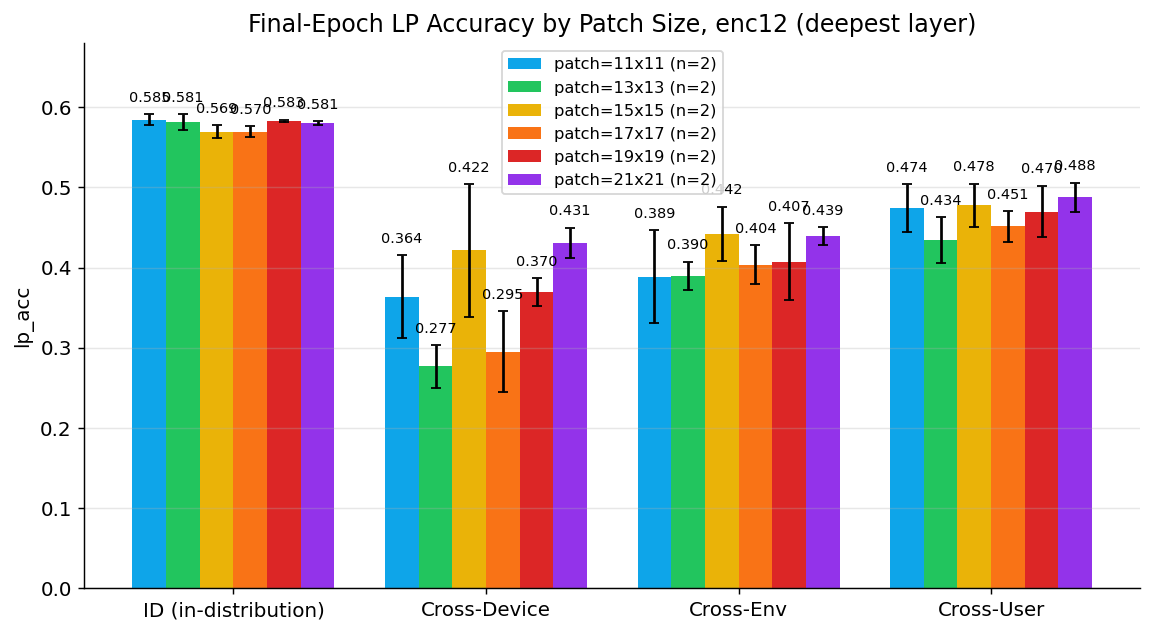

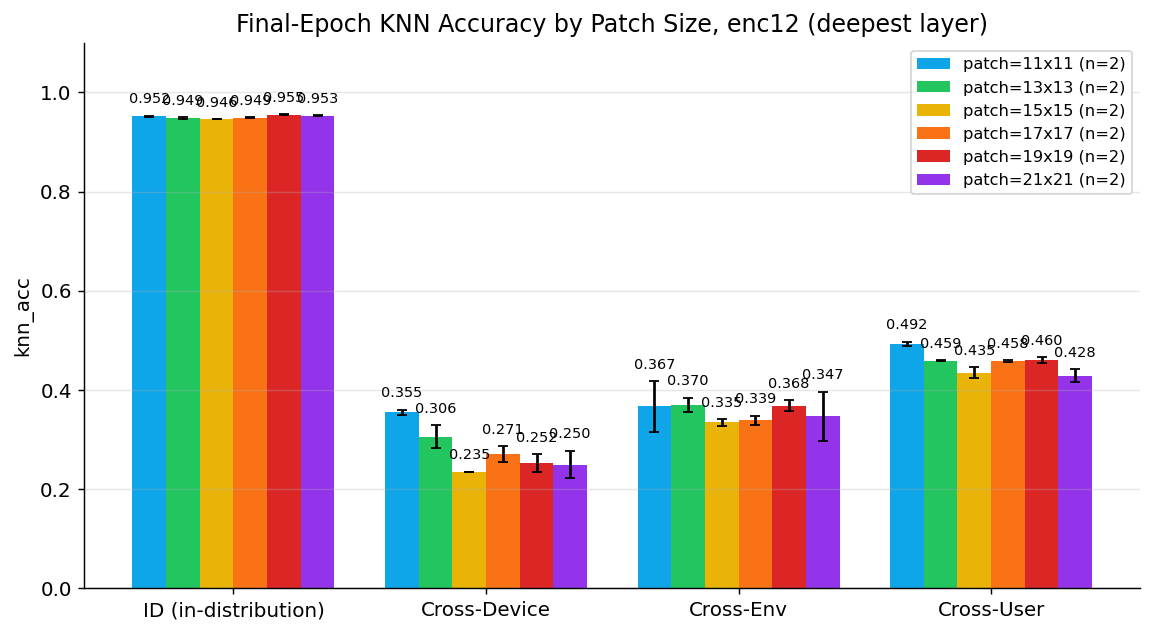

In [126]:
if patch_enc12_groups:
    plot_final_accuracy_by_group(
        patch_enc12_groups, FIG_DIR, "patch_enc12_bar_lp_acc.png",
        title="Final-Epoch LP Accuracy by Patch Size, enc12 (deepest layer)",
        metric="lp_acc", colors=GROUP_COLORS, group_label_fmt="patch={k}x{k}",
    )
    plot_final_accuracy_by_group(
        patch_enc12_groups, FIG_DIR, "patch_enc12_bar_knn_acc.png",
        title="Final-Epoch KNN Accuracy by Patch Size, enc12 (deepest layer)",
        metric="knn_acc", colors=GROUP_COLORS, group_label_fmt="patch={k}x{k}",
    )

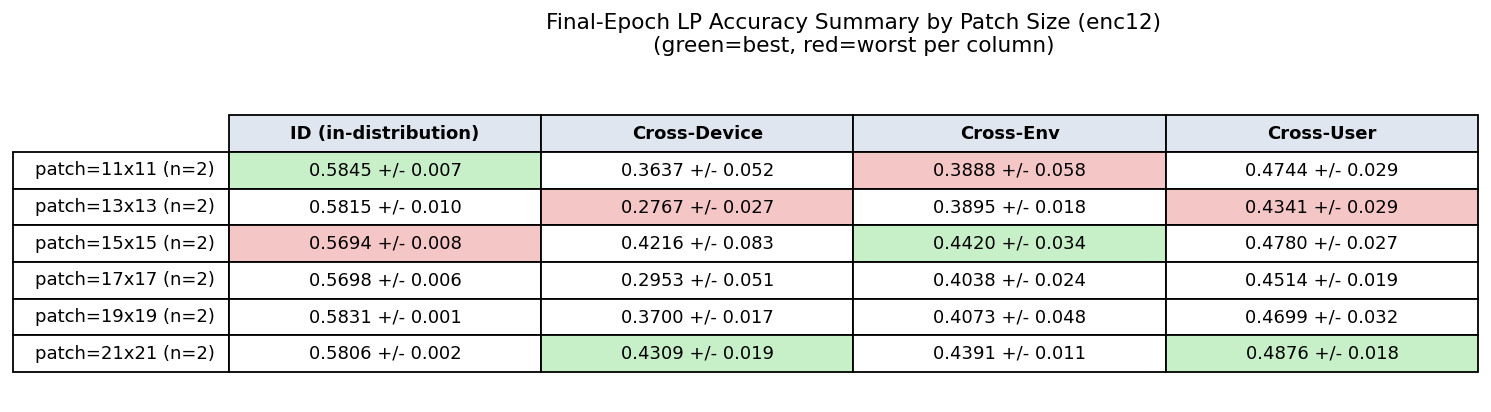

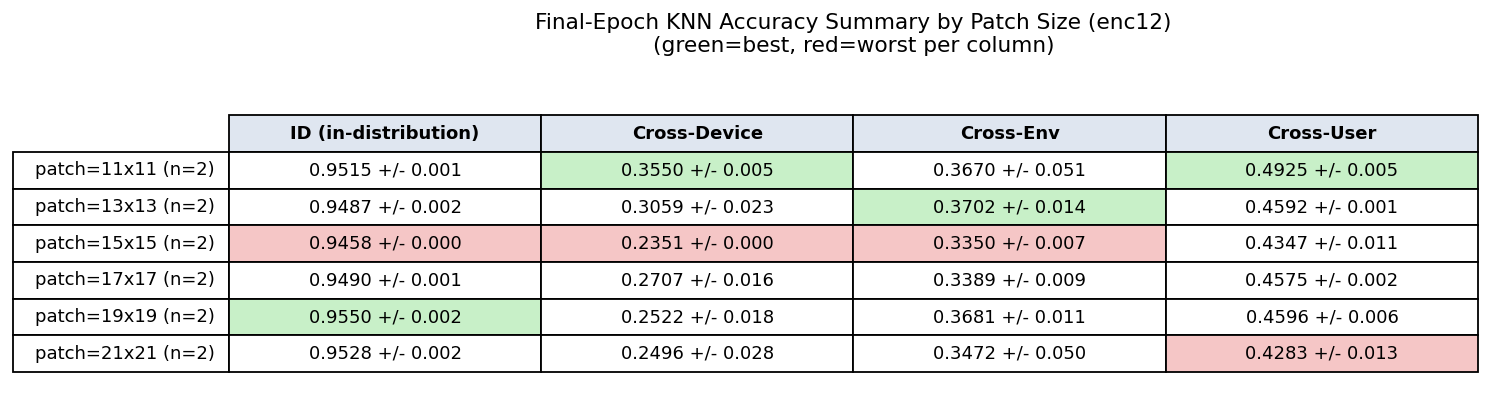


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.5845 +/- 0.007        0.3637 +/- 0.052        0.3888 +/- 0.058        0.4744 +/- 0.029
patch=13x13           0.5815 +/- 0.010        0.2767 +/- 0.027        0.3895 +/- 0.018        0.4341 +/- 0.029
patch=15x15           0.5694 +/- 0.008        0.4216 +/- 0.083        0.4420 +/- 0.034        0.4780 +/- 0.027
patch=17x17           0.5698 +/- 0.006        0.2953 +/- 0.051        0.4038 +/- 0.024        0.4514 +/- 0.019
patch=19x19           0.5831 +/- 0.001        0.3700 +/- 0.017        0.4073 +/- 0.048        0.4699 +/- 0.032
patch=21x21           0.5806 +/- 0.002        0.4309 +/- 0.019        0.4391 +/- 0.011        0.4876 +/- 0.018

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.9515 +/- 0.001 

In [127]:
if patch_enc12_groups:
    plot_summary_table_image(
        patch_enc12_groups, FIG_DIR, "patch_enc12_table_lp_acc.png",
        title="Final-Epoch LP Accuracy Summary by Patch Size (enc12)",
        metric="lp_acc", group_label_fmt="patch={k}x{k}",
    )

    plot_summary_table_image(
        patch_enc12_groups, FIG_DIR, "patch_enc12_table_knn_acc.png",
        title="Final-Epoch KNN Accuracy Summary by Patch Size (enc12)",
        metric="knn_acc", group_label_fmt="patch={k}x{k}",
    )

    print_summary_table(patch_enc12_groups, metric="lp_acc", group_label_fmt="patch={k}x{k}")
    print_summary_table(patch_enc12_groups, metric="knn_acc", group_label_fmt="patch={k}x{k}")

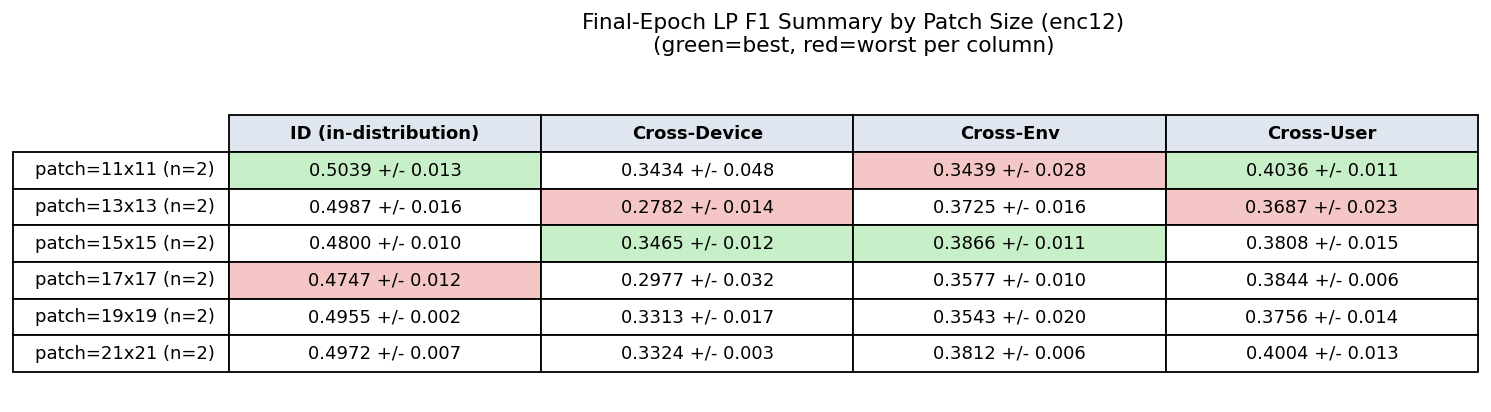

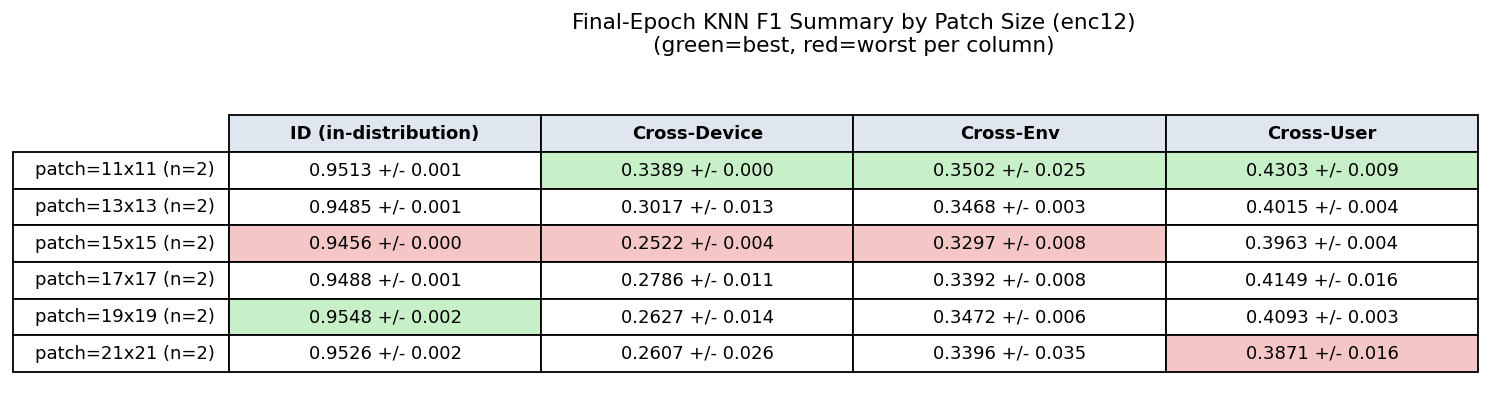


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.5039 +/- 0.013        0.3434 +/- 0.048        0.3439 +/- 0.028        0.4036 +/- 0.011
patch=13x13           0.4987 +/- 0.016        0.2782 +/- 0.014        0.3725 +/- 0.016        0.3687 +/- 0.023
patch=15x15           0.4800 +/- 0.010        0.3465 +/- 0.012        0.3866 +/- 0.011        0.3808 +/- 0.015
patch=17x17           0.4747 +/- 0.012        0.2977 +/- 0.032        0.3577 +/- 0.010        0.3844 +/- 0.006
patch=19x19           0.4955 +/- 0.002        0.3313 +/- 0.017        0.3543 +/- 0.020        0.3756 +/- 0.014
patch=21x21           0.4972 +/- 0.007        0.3324 +/- 0.003        0.3812 +/- 0.006        0.4004 +/- 0.013

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.9513 +/- 0.001   

In [128]:
if patch_enc12_groups:
    plot_summary_table_image(
        patch_enc12_groups, FIG_DIR, "patch_enc12_table_lp_f1.png",
        title="Final-Epoch LP F1 Summary by Patch Size (enc12)",
        metric="lp_f1", group_label_fmt="patch={k}x{k}",
    )

    plot_summary_table_image(
        patch_enc12_groups, FIG_DIR, "patch_enc12_table_knn_f1.png",
        title="Final-Epoch KNN F1 Summary by Patch Size (enc12)",
        metric="knn_f1", group_label_fmt="patch={k}x{k}",
    )

    print_summary_table(patch_enc12_groups, metric="lp_f1", group_label_fmt="patch={k}x{k}")
    print_summary_table(patch_enc12_groups, metric="knn_f1", group_label_fmt="patch={k}x{k}")

**Cross-check against the enc6 version.** If `patch_groups` (Section C) is already loaded in this
kernel session, this compares both encoder depths side by side for `lp_acc` -- note the enc6 sweep
includes `patch=11` which has no enc12 counterpart (unsafe at that depth), so the two series only
overlap at `patch=13`.

In [129]:
if patch_groups and patch_enc12_groups:
    print("=== enc6 (Section C) ===")
    print_summary_table(patch_groups, metric="lp_acc", group_label_fmt="patch={k}x{k}")
    print("\n=== enc12 (Section E) ===")
    print_summary_table(patch_enc12_groups, metric="lp_acc", group_label_fmt="patch={k}x{k}")
else:
    print("Run Section C\'s cells first in this kernel session to enable the enc6-vs-enc12 comparison.")

=== enc6 (Section C) ===

=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.5623 +/- 0.004        0.3926 +/- 0.025        0.3664 +/- 0.010        0.4789 +/- 0.032
patch=13x13           0.5741 +/- 0.003        0.3893 +/- 0.031        0.4403 +/- 0.029        0.4584 +/- 0.021
patch=15x15           0.5652 +/- 0.005        0.4191 +/- 0.002        0.4352 +/- 0.016        0.4810 +/- 0.014
patch=17x17           0.5679 +/- 0.002        0.4638 +/- 0.011        0.4733 +/- 0.018        0.4844 +/- 0.012
patch=19x19           0.5625 +/- 0.001        0.3146 +/- 0.032        0.4029 +/- 0.008        0.4135 +/- 0.002

=== enc12 (Section E) ===

=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.5845 +/- 0.007        0.3637 +/- 0.052        0.3888 +/- 0.058        0.474

## Notes / caveats

- **Sample size (n) matters.** Every bar chart / table shows `n` per group in the legend or row
  label. If a group shows `n=1` where you expect `n=2` (missing seed), or `n=3` where you expect
  `n=2` (a stray unseeded run got picked up by the filter), treat that group's numbers as
  provisional -- re-check `RATIO_FILTERS` / `STRATEGY_FILTERS` and the underlying files before
  drawing conclusions.
- **`DEBUG=True`** in either config cell prints a per-file `[match]` / `[skip: reason]` line, which
  is the fastest way to find out why a file was excluded (wrong `mask_ratio`, missing `patch_h`,
  wrong `encoder_depth`, etc.).
- The **enc12 layer-probing job (Section A)** may still be running -- ratios/seeds with fewer
  runs than expected likely just haven't finished yet, not necessarily a data problem.